# Проект: Прогнозирование оттока клиентов

## Введение

Оператор связи сталкивается с проблемой оттока клиентов. Для снижения потерь компания планирует заблаговременно предлагать промокоды и специальные условия тем, кто собирается разорвать договор. Чтобы автоматизировать выявление таких пользователей, требуется построить модель машинного обучения, способную по историческим данным предсказывать вероятность разрыва договора.

## Цель исследования

Построить модель, которая по данным о клиенте предсказывает вероятность разрыва клиентом договора. <br>
Основная метрика: ROC-AUC ≥ 0.85 на тестовой выборке.

## Описание данных

Данные хранятся в файле SQLite (один файл .db) и состоят из четырёх таблиц:

**Таблица contract:**
- customerID — ID абонента;
- BeginDate — дата начала действия договора;
- EndDate — дата окончания действия договора;
- Type — тип оплаты: раз в год-два или ежемесячно;
- PaperlessBilling — электронный расчётный лист;
- PaymentMethod — тип платежа;
- MonthlyCharges — расходы за месяц;
- TotalCharges — общие расходы абонента.

**Таблица personal:**
- customerID — ID пользователя;
- gender — пол;
- SeniorCitizen — является ли абонент пенсионером;
- Partner — есть ли у абонента супруг или супруга;
- Dependents — есть ли у абонента дети.
   
**Таблица internet:**
- customerID — ID пользователя;
- InternetService — тип подключения;
- OnlineSecurity — блокировка опасных сайтов;
- OnlineBackup — облачное хранилище файлов для резервного копирования данных;
- DeviceProtection — антивирус;
- TechSupport — выделенная линия технической поддержки;
- StreamingTV — стриминговое телевидение;
- StreamingMovies — каталог фильмов.
  
**Таблица phone:**
- customerID — ID пользователя;
- MultipleLines — подключение телефона к нескольким линиям одновременно.
  

## План исследования

* [Загрузка данных](#link1)
* [Предобработка данных](#link2)
* [Исследовательский анализ](#link3)
* [Обучение моделей](#link4)
* [Оценка моделей](#link5)
* [Оценка важности признаков](#link6)
* [Выводы](#link7)

## Подготовка рабочего пространства

In [1]:
# импортируем необходимые библиотеки
import os
import wget
import pandas as pd
from sqlalchemy import create_engine
import re
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import phik
from phik import resources
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, precision_score, recall_score
from lightgbm import LGBMClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from scikeras.wrappers import KerasClassifier
import shap

from sklearn.feature_selection import mutual_info_classif
import tensorflow as tf
from sklearn.dummy import DummyClassifier

# импортируем функции из моего модуля
from ds_lib_tatarnikov import (
    to_snake_case,
    data_overview,
    show_pie,
    show_2_pies,
    show_plot,
    show_2_plots,
    print_corr_levels,
    print_corr_levels_target
)

# зададим константы
RANDOM_STATE = 11225 # требование заказчика
TEST_SIZE = 0.25

# настройки отображения таблиц
pd.options.display.max_columns = None

# отключим предупреждения
import warnings
warnings.filterwarnings("ignore", message="set_ticklabels")
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

<a class='anchor' id="link1"></a>
## 1 Загрузка данных

**1.1 Подключение к базе данных** 

In [2]:
path_to_db = 'ds-plus-final.db'
url = 'https://code.s3.yandex.net/data-scientist/ds-plus-final.db'

# Если файла нет — скачиваем
if not os.path.exists(path_to_db):
    wget.download(url, path_to_db)

# Проверяем, что файл появился
assert os.path.exists(path_to_db), "Файл базы данных не найден"

# Подключаемся
engine = create_engine(f'sqlite:///{path_to_db}', echo=False)

**1.2 Загрузка данных**

In [3]:
contract_df = pd.read_sql('SELECT * FROM contract', con=engine)
personal_df = pd.read_sql('SELECT * FROM personal', con=engine)
internet_df = pd.read_sql('SELECT * FROM internet', con=engine)
phone_df = pd.read_sql('SELECT * FROM phone', con=engine)

**1.3 Общая информация о таблицах**

In [4]:
data_overview(contract_df, 'с информацией о договорах')

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.3,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.7,353.5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7043 non-null   object
 1   BeginDate         7043 non-null   object
 2   EndDate           7043 non-null   object
 3   Type              7043 non-null   object
 4   PaperlessBilling  7043 non-null   object
 5   PaymentMethod     7043 non-null   object
 6   MonthlyCharges    7043 non-null   object
 7   TotalCharges      7043 non-null   object
dtypes: object(8)
memory usage: 440.3+ KB

Таблица с информацией о договорах состоит из 7043 строк и 8 столбцов.
Пропусков нет.


In [5]:
data_overview(personal_df, 'с персональными данными клиентов')

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   object
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: object(5)
memory usage: 275.2+ KB

Таблица с персональными данными клиентов состоит из 7043 строк и 5 столбцов.
Пропусков нет.


In [6]:
data_overview(internet_df, 'с информацией об интернет-услугах')

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB

Таблица с информацией об интернет-услугах состоит из 5517 строк и 8 столбцов.
Пропусков нет.


In [7]:
data_overview(phone_df, 'с информацией об услугах телефонии')

,CustomerId,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerId     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB

Таблица с информацией об услугах телефонии состоит из 6361 строки и 2 столбцов.
Пропусков нет.


**Промежуточный итог:**

Данные успешно загружены. Пропусков в таблицах. Названия столбцов нужно привести к единому змеинному стилю. Необходимо преобразовать типы данных: столбцы с датами привести к типу 'datetime', числовые данные привести к соответствующим числовым типам, категориальные признаки оставим 'object'.

<a class='anchor' id="link2"></a>
## 2 Предобработка данных

**2.1 Приведем названия столбцов к общему стилю**

In [8]:
tables = [contract_df, personal_df, internet_df, phone_df]

for i in range(len(tables)):
    tables[i].columns = [to_snake_case(c) for c in tables[i].columns]
    display(tables[i].head())

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.3,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.7,353.5


,customer_id,gender,senior_citizen,partner,dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


,customer_id,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


,customer_id,multiple_lines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


**2.2 Преобразование типов**

**contract_df**

In [9]:
contract_df['begin_date'] = pd.to_datetime(contract_df['begin_date'])

contract_df['end_date'] = pd.to_datetime(
    contract_df['end_date'],
    errors='coerce'
)

contract_df['monthly_charges'] = pd.to_numeric(contract_df['monthly_charges'], errors='coerce')
contract_df['total_charges'] = pd.to_numeric(contract_df['total_charges'], errors='coerce')

display(contract_df.head())
contract_df.info()

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,NaT,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,1960.60
4,9237-HQITU,2019-09-01,NaT,Month-to-month,Yes,Electronic check,70.70,353.50


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        7043 non-null   object        
 1   begin_date         7043 non-null   datetime64[ns]
 2   end_date           1101 non-null   datetime64[ns]
 3   type               7043 non-null   object        
 4   paperless_billing  7043 non-null   object        
 5   payment_method     7043 non-null   object        
 6   monthly_charges    7043 non-null   float64       
 7   total_charges      7032 non-null   float64       
dtypes: datetime64[ns](2), float64(2), object(4)
memory usage: 440.3+ KB


In [10]:
cols = ['type', 'paperless_billing', 'payment_method']
for col in cols:
    print(list(contract_df[col].unique()))

['Month-to-month', 'One year', 'Two year']
['Yes', 'No']
['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']


**personal_df**

In [11]:
personal_df['senior_citizen'] = pd.to_numeric(personal_df['senior_citizen'], errors='coerce').astype('Int64')

display(personal_df.head())
personal_df.info()

,customer_id,gender,senior_citizen,partner,dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     7043 non-null   object
 1   gender          7043 non-null   object
 2   senior_citizen  7043 non-null   Int64 
 3   partner         7043 non-null   object
 4   dependents      7043 non-null   object
dtypes: Int64(1), object(4)
memory usage: 282.1+ KB


In [12]:
cols = ['gender', 'partner', 'dependents', 'senior_citizen']
for col in cols:
    print(list(personal_df[col].unique()))

['Female', 'Male']
['Yes', 'No']
['No', 'Yes']
[0, 1]


**internet_df**

In [13]:
binary_cols = ['online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies']

for col in binary_cols:
    internet_df[col] = (
        internet_df[col]
        .map({'Yes': 1, 'No': 0})
        .astype('Int64')
    )

display(internet_df.head())
internet_df.info()

,customer_id,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies
0,7590-VHVEG,DSL,0,1,0,0,0,0
1,5575-GNVDE,DSL,1,0,1,0,0,0
2,3668-QPYBK,DSL,1,1,0,0,0,0
3,7795-CFOCW,DSL,1,0,1,1,0,0
4,9237-HQITU,Fiber optic,0,0,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        5517 non-null   object
 1   internet_service   5517 non-null   object
 2   online_security    5517 non-null   Int64 
 3   online_backup      5517 non-null   Int64 
 4   device_protection  5517 non-null   Int64 
 5   tech_support       5517 non-null   Int64 
 6   streaming_tv       5517 non-null   Int64 
 7   streaming_movies   5517 non-null   Int64 
dtypes: Int64(6), object(2)
memory usage: 377.3+ KB


In [14]:
cols = ["internet_service", "online_security", "online_backup", "device_protection", "tech_support", "streaming_tv", "streaming_movies"]
for col in cols:
    print(list(internet_df[col].unique()))

['DSL', 'Fiber optic']
[0, 1]
[1, 0]
[0, 1]
[0, 1]
[0, 1]
[0, 1]


**phone_df**

In [15]:
phone_df['multiple_lines'] = phone_df['multiple_lines'].map({'Yes': 1, 'No': 0}).astype('Int64')

display(phone_df.head())
phone_df.info()

,customer_id,multiple_lines
0,5575-GNVDE,0
1,3668-QPYBK,0
2,9237-HQITU,0
3,9305-CDSKC,1
4,1452-KIOVK,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     6361 non-null   object
 1   multiple_lines  6361 non-null   Int64 
dtypes: Int64(1), object(1)
memory usage: 105.7+ KB


In [16]:
print(list(phone_df['multiple_lines'].unique()))

[0, 1]


После преобразования типов в таблицах появились пропуски.<br>
[Обработаем их в разделе 2.6](#link2.6)

**2.3 Поиск дубликатов**

In [17]:
print(contract_df.duplicated().sum())
print(personal_df.duplicated().sum())
print(internet_df.duplicated().sum())
print(phone_df.duplicated().sum())

0
0
0
0


Явных дубликатов нет

**2.4 Объединение таблиц**

Количество строк в таблицах с договорами и клиентами одинаковое. Сравним уникальных пользователей в двух таблицах.

In [18]:
set(contract_df['customer_id'].unique()) - set(personal_df['customer_id'].unique())

set()

Клиенты в двух таблицах полностью совпадают.

Количество строк в таблицах с интернет-услугами и услугами телефонии меньше, чем в таблице с договорами.

In [19]:
set(contract_df['customer_id'].unique()) - set(internet_df['customer_id'].unique()) - set(phone_df['customer_id'].unique())

set()

В данных таблица имеется информация обо всех клиентах из таблицы с договорами.

Объединим таблицы по столбцу 'customer_id'.

In [20]:
merged_df = contract_df \
    .merge(personal_df, on='customer_id', how='left') \
    .merge(internet_df, on='customer_id', how='left') \
    .merge(phone_df, on='customer_id', how='left')

In [21]:
merged_df.head()

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,31.04,Female,0,Yes,No,DSL,0,1,0,0,0,0,<NA>
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,2071.84,Male,0,No,No,DSL,1,0,1,0,0,0,0
2,3668-QPYBK,2019-10-01,NaT,Month-to-month,Yes,Mailed check,53.85,226.17,Male,0,No,No,DSL,1,1,0,0,0,0,0
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,1960.60,Male,0,No,No,DSL,1,0,1,1,0,0,<NA>
4,9237-HQITU,2019-09-01,NaT,Month-to-month,Yes,Electronic check,70.70,353.50,Female,0,No,No,Fiber optic,0,0,0,0,0,0,0


In [22]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        7043 non-null   object        
 1   begin_date         7043 non-null   datetime64[ns]
 2   end_date           1101 non-null   datetime64[ns]
 3   type               7043 non-null   object        
 4   paperless_billing  7043 non-null   object        
 5   payment_method     7043 non-null   object        
 6   monthly_charges    7043 non-null   float64       
 7   total_charges      7032 non-null   float64       
 8   gender             7043 non-null   object        
 9   senior_citizen     7043 non-null   Int64         
 10  partner            7043 non-null   object        
 11  dependents         7043 non-null   object        
 12  internet_service   5517 non-null   object        
 13  online_security    5517 non-null   Int64         
 14  online_b

Посмотрим на неявные дубликаты.

In [23]:
merged_df[merged_df.drop('customer_id', axis=1).duplicated()]['customer_id'].count()

4

In [24]:
merged_df[merged_df.drop('customer_id', axis=1).duplicated(keep=False)].sort_values(by='monthly_charges')

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines
542,2866-IKBTM,2020-01-01,NaT,Month-to-month,No,Mailed check,19.55,19.55,Female,0,No,No,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0
1491,8605-ITULD,2020-01-01,NaT,Month-to-month,No,Mailed check,19.55,19.55,Female,0,No,No,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0
2121,0673-IGUQO,2020-01-01,NaT,Month-to-month,No,Mailed check,20.45,20.45,Male,0,No,No,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0
2892,2668-TZSPS,2020-01-01,NaT,Month-to-month,No,Mailed check,20.45,20.45,Male,0,No,No,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0
714,4312-KFRXN,2014-02-01,NaT,Two year,No,Mailed check,25.40,1828.80,Male,0,Yes,No,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1
5024,8774-GSBUN,2014-02-01,NaT,Two year,No,Mailed check,25.40,1828.80,Male,0,Yes,No,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1
437,4376-KFVRS,2014-02-01,NaT,Two year,Yes,Credit card (automatic),114.05,8211.60,Male,0,Yes,Yes,Fiber optic,1,1,1,1,1,1,1
4797,3892-NXAZG,2014-02-01,NaT,Two year,Yes,Credit card (automatic),114.05,8211.60,Male,0,Yes,Yes,Fiber optic,1,1,1,1,1,1,1


Имеется 4 пары клиентов, у которых совпадают все данные кроме id. Предполагается, что для таблицы из более 7000 клиентов, наличие нескольких дубликатов в данных о подключеных услугах и платежах естественно и не является ошибкой.

**2.5 Создание новых признаков**

Добавим целевой признак 'end', обозначающий факт расторжения договора.

In [25]:
merged_df['end'] = merged_df['end_date'].notna().astype(int)
merged_df['end'].value_counts()

0    5942
1    1101
Name: end, dtype: int64

Создадим признаки, обозначающие наличие интернет подключения и наличия телефонного подключения.

In [26]:
# Наличие интернет-подключения
merged_df['has_internet'] = merged_df['internet_service'].notna().astype(int)

# Наличие телефонного подключения
merged_df['has_phone'] = merged_df['multiple_lines'].notna().astype(int)

Создадим признак с количеством дополнительных интернет услуг.

In [27]:
service_cols = [
    'online_security',
    'online_backup',
    'device_protection',
    'tech_support',
    'streaming_tv',
    'streaming_movies',
    'multiple_lines'
]

merged_df['num_services'] = merged_df[service_cols].fillna(0).sum(axis=1)

Создадим признак 'duration_to_end', обозначающий длительность договора до момента разрыва. Используем этот признак только для анализа. Для избежания утечки целевого признака для обучения использовать этот признак не будем.

In [28]:
merged_df['duration_to_end'] = (merged_df['end_date'] - merged_df['begin_date']).dt.days

Для сравнения создадим признак 'current_duration' для длительности текущих контрактов.

In [29]:
reference_date = pd.to_datetime('2020-02-01')
merged_df.loc[pd.isna(merged_df['duration_to_end']), 'current_duration'] = (
    (reference_date - merged_df['begin_date']).dt.days
)

И добавим признак 'days_since_begin_date' (дней с момента заключения договора). Для всех абонентов, а не только для для текущих.

In [30]:
# Создаем признак количества дней с начала договора
merged_df['days_since_begin_date'] = (reference_date - merged_df['begin_date']).dt.days

Добавим признаки длительность контракта, длительность контракта в месяцах и длительность контракта в месяцах умноженная на ежемесячный платеж (для сравнения с общими тратами)

In [31]:
merged_df['contract_duration'] = (
    merged_df['duration_to_end'].fillna(0) + 
    merged_df['current_duration'].fillna(0)
)

merged_df['contract_duration (months)'] = merged_df['contract_duration']/30
merged_df['contract_duration (months) * monthly_charges'] = merged_df['contract_duration (months)'] * merged_df['monthly_charges']

In [32]:
merged_df.iloc[1:11]

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines,end,has_internet,has_phone,num_services,duration_to_end,current_duration,days_since_begin_date,contract_duration,contract_duration (months),contract_duration (months) * monthly_charges
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,2071.84,Male,0,No,No,DSL,1,0,1,0,0,0,0,0,1,1,2.0,NaN,1036.0,1036,1036.0,34.533333,1966.673333
2,3668-QPYBK,2019-10-01,NaT,Month-to-month,Yes,Mailed check,53.85,226.17,Male,0,No,No,DSL,1,1,0,0,0,0,0,0,1,1,2.0,NaN,123.0,123,123.0,4.100000,220.785000
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,1960.60,Male,0,No,No,DSL,1,0,1,1,0,0,<NA>,0,1,0,3.0,NaN,1371.0,1371,1371.0,45.700000,1933.110000
4,9237-HQITU,2019-09-01,NaT,Month-to-month,Yes,Electronic check,70.70,353.50,Female,0,No,No,Fiber optic,0,0,0,0,0,0,0,0,1,1,0.0,NaN,153.0,153,153.0,5.100000,360.570000
5,9305-CDSKC,2019-03-01,NaT,Month-to-month,Yes,Electronic check,99.65,1150.96,Female,0,No,No,Fiber optic,0,0,1,0,1,1,1,0,1,1,4.0,NaN,337.0,337,337.0,11.233333,1119.401667
6,1452-KIOVK,2018-04-01,NaT,Month-to-month,Yes,Credit card (automatic),89.10,2058.21,Male,0,No,Yes,Fiber optic,0,1,0,0,1,0,1,0,1,1,3.0,NaN,671.0,671,671.0,22.366667,1992.870000
7,6713-OKOMC,2019-04-01,NaT,Month-to-month,No,Mailed check,29.75,300.48,Female,0,No,No,DSL,1,0,0,0,0,0,<NA>,0,1,0,1.0,NaN,306.0,306,306.0,10.200000,303.450000
8,7892-POOKP,2017-07-01,NaT,Month-to-month,Yes,Electronic check,104.80,3573.68,Female,0,Yes,No,Fiber optic,0,0,1,1,1,1,1,0,1,1,5.0,NaN,945.0,945,945.0,31.500000,3301.200000
9,6388-TABGU,2014-12-01,2017-05-01,One year,No,Bank transfer (automatic),56.15,1628.35,Male,0,No,Yes,DSL,1,1,0,0,0,0,0,1,1,1,2.0,882.0,NaN,1888,882.0,29.400000,1650.810000
10,9763-GRSKD,2019-01-01,NaT,Month-to-month,Yes,Mailed check,49.95,649.35,Male,0,Yes,Yes,DSL,1,0,0,0,0,0,0,0,1,1,1.0,NaN,396.0,396,396.0,13.200000,659.340000


<a class='anchor' id="link2.6"></a>
**2.6 Обработка пропусков**

Заполним пропуски в категориальных и бинарных признаках отдельной категорией, что будет обозначать отсутствие сервиса у клиента, либо не применимость этого признака для данного клиента.

In [33]:
binary_or_categorical_columns = [
    'internet_service', 'online_security', 'online_backup',
    'device_protection', 'tech_support', 'streaming_tv',
    'streaming_movies', 'multiple_lines'
]

for col in binary_or_categorical_columns:
    if merged_df[col].dtype == 'object':        # категориальные признаки
        merged_df[col] = merged_df[col].fillna('no_service')
    else:                                       # бинарные числовые
        merged_df[col] = merged_df[col].fillna(-1)

Удалим строки с пропусками в столбце total_charges

In [34]:
merged_df = merged_df.dropna(subset=['total_charges'])

In [35]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7032 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   customer_id                                   7032 non-null   object        
 1   begin_date                                    7032 non-null   datetime64[ns]
 2   end_date                                      1101 non-null   datetime64[ns]
 3   type                                          7032 non-null   object        
 4   paperless_billing                             7032 non-null   object        
 5   payment_method                                7032 non-null   object        
 6   monthly_charges                               7032 non-null   float64       
 7   total_charges                                 7032 non-null   float64       
 8   gender                                        7032 non-null   object

Пропуски остались только в столбцах связанных с длительностью договора.

**Промежуточный итог:**

Данные были объединены в единую таблицу. Типы данных приведены в соответствие с данными. Названия признаков приведены к общепринятому змеинному стилю. Произвен поиск дубликатов, дубликатов не обнаружено. Созданы новые признаки. Обработаны пропуски. Данные подготовлены к проведению исcледовательского анализа.

<a class='anchor' id="link3"></a>
## 3 Исследовательский анализ

**3.1 Статистический анализ**

Выведем статистическое описание

In [36]:
merged_df.describe(include='all')

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines,end,has_internet,has_phone,num_services,duration_to_end,current_duration,days_since_begin_date,contract_duration,contract_duration (months),contract_duration (months) * monthly_charges
count,7032,7032,1101,7032,7032,7032,7032.000000,7032.000000,7032,7032.000000,7032,7032,7032,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,1101.000000,5931.000000,7032.000000,7032.000000,7032.000000,7032.000000
unique,7032,76,66,3,2,4,NaN,NaN,2,NaN,2,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,5138-WVKYJ,2014-02-01 00:00:00,2020-01-01 00:00:00,Month-to-month,Yes,Electronic check,NaN,NaN,Male,NaN,No,No,Fiber optic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,366,39,3875,4168,2365,NaN,NaN,3549,NaN,3639,4933,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first,NaN,2013-10-01 00:00:00,2014-06-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last,NaN,2020-01-01 00:00:00,2020-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,64.798208,2118.621822,NaN,0.162400,NaN,NaN,NaN,0.070392,0.128697,0.127702,0.073948,0.168231,0.172213,0.325228,0.156570,0.783845,0.903299,2.460040,924.863760,895.338560,1008.031428,899.961320,29.998711,2093.758559
std,NaN,NaN,NaN,NaN,NaN,NaN,30.085974,2112.736199,NaN,0.368844,NaN,NaN,NaN,0.705562,0.737917,0.737415,0.707715,0.756518,0.758252,0.642585,0.363421,0.411650,0.295571,2.045311,458.771309,716.588322,736.095040,682.738777,22.757959,2085.910638
min,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,19.050000,NaN,0.000000,NaN,NaN,NaN,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,28.000000,31.000000,31.000000,28.000000,0.933333,19.426667
25%,NaN,NaN,NaN,NaN,NaN,NaN,35.587500,439.745000,NaN,0.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,577.000000,245.000000,306.000000,276.000000,9.200000,439.968750


В базе предоставленны данные о договорах с 01 октября 2013 года по 01 января 2020 года. Распределения данных соответствуют данным, явных выбросов и аномалий нет. 

**3.2 Визуализация статистических данных**

Для красивой визуализации переведем таблицу на русский язык.

In [37]:
eng_to_rus_cols = {
    "customer_id": "ID клиента",
    "begin_date": "Дата начала договора",
    "end_date": "Дата окончания договора",
    "type": "Тип оплаты",
    "paperless_billing": "Электронный счет",
    "payment_method": "Способ оплаты",
    "monthly_charges": "Ежемесячные расходы",
    "total_charges": "Общие расходы",
    "gender": "Пол",
    "senior_citizen": "Пенсионер",
    "partner": "Есть супруг/супруга",
    "dependents": "Есть дети",
    "internet_service": "Тип интернет-подключения",
    "online_security": "Блокировка опасных сайтов",
    "online_backup": "Облачное резервное копирование",
    "device_protection": "Антивирус",
    "tech_support": "Техподдержка",
    "streaming_tv": "Стриминговое ТВ",
    "streaming_movies": "Стриминговые фильмы",
    "multiple_lines": "Несколько телефонных линий",
    "end": "Договор расторгнут",
    "has_internet": "Есть интернет",
    "has_phone": "Есть телефон",
    "num_services": "Количество доп. услуг",
    "duration_to_end": "Длительность до расторжения (дни)",
    "current_duration": "Текущая длительность контракта (дни)",
    "days_since_begin_date": "Дней с момента заключения договора",
    "contract_duration": "Длительность контракта",
    "contract_duration (months)": "Длительность контракта (месяцев)",
    "contract_duration (months) * monthly_charges": "Длительность контракта (месяцев) * Месячный платеж"
}

In [38]:
eng_to_rus_values = {
    # Типы договора
    "Month-to-month": "Помесячно",
    "One year": "1 год",
    "Two year": "2 года",

    # Способы оплаты
    "Electronic check": "Электронный чек",
    "Mailed check": "Почтовый чек",
    "Bank transfer (automatic)": "Автоплатеж (перевод)",
    "Credit card (automatic)": "Автоплатеж (карта)",

    # Интернет-подключение
    "DSL": "DSL",
    "Fiber optic": "Оптоволокно",
    "no_service": "Нет интернета",
}

In [39]:
merged_df_rus = merged_df.copy()

# Переводим названия столбцов
merged_df_rus.rename(columns=eng_to_rus_cols, inplace=True)

# Переводим значения
merged_df_rus = merged_df_rus.replace(eng_to_rus_values)

cols = [
    "Пенсионер",
    "Блокировка опасных сайтов",
    "Облачное резервное копирование",
    "Антивирус",
    "Техподдержка",
    "Стриминговое ТВ",
    "Стриминговые фильмы",
    "Несколько телефонных линий",
    "Договор расторгнут",
    "Есть интернет",
    "Есть телефон",
]
map = {-1: "Не применимо", 0: "Нет", 1: "Да"}
for col in cols:
    merged_df_rus[col] = merged_df_rus[col].map(map)

cols2 = [
    "Электронный счет",
    "Есть супруг/супруга",
    "Есть дети"
]
map2 = {"No": "Нет", "Yes": "Да"}
for col in cols2:
    merged_df_rus[col] = merged_df_rus[col].map(map2)


binary_map = {"Female": "Женщина", "Male": "Мужчина"}
merged_df_rus['Пол'] = merged_df_rus['Пол'].map(binary_map)


merged_df_rus.head()

,ID клиента,Дата начала договора,Дата окончания договора,Тип оплаты,Электронный счет,Способ оплаты,Ежемесячные расходы,Общие расходы,Пол,Пенсионер,Есть супруг/супруга,Есть дети,Тип интернет-подключения,Блокировка опасных сайтов,Облачное резервное копирование,Антивирус,Техподдержка,Стриминговое ТВ,Стриминговые фильмы,Несколько телефонных линий,Договор расторгнут,Есть интернет,Есть телефон,Количество доп. услуг,Длительность до расторжения (дни),Текущая длительность контракта (дни),Дней с момента заключения договора,Длительность контракта,Длительность контракта (месяцев),Длительность контракта (месяцев) * Месячный платеж
0,7590-VHVEG,2020-01-01,NaT,Помесячно,Да,Электронный чек,29.85,31.04,Женщина,Нет,Да,Нет,DSL,Нет,Да,Нет,Нет,Нет,Нет,Не применимо,Нет,Да,Нет,1.0,NaN,31.0,31,31.0,1.033333,30.845000
1,5575-GNVDE,2017-04-01,NaT,1 год,Нет,Почтовый чек,56.95,2071.84,Мужчина,Нет,Нет,Нет,DSL,Да,Нет,Да,Нет,Нет,Нет,Нет,Нет,Да,Да,2.0,NaN,1036.0,1036,1036.0,34.533333,1966.673333
2,3668-QPYBK,2019-10-01,NaT,Помесячно,Да,Почтовый чек,53.85,226.17,Мужчина,Нет,Нет,Нет,DSL,Да,Да,Нет,Нет,Нет,Нет,Нет,Нет,Да,Да,2.0,NaN,123.0,123,123.0,4.100000,220.785000
3,7795-CFOCW,2016-05-01,NaT,1 год,Нет,Автоплатеж (перевод),42.30,1960.60,Мужчина,Нет,Нет,Нет,DSL,Да,Нет,Да,Да,Нет,Нет,Не применимо,Нет,Да,Нет,3.0,NaN,1371.0,1371,1371.0,45.700000,1933.110000
4,9237-HQITU,2019-09-01,NaT,Помесячно,Да,Электронный чек,70.70,353.50,Женщина,Нет,Нет,Нет,Оптоволокно,Нет,Нет,Нет,Нет,Нет,Нет,Нет,Нет,Да,Да,0.0,NaN,153.0,153,153.0,5.100000,360.570000


Визуализируем количество новых договоров по месяцам.

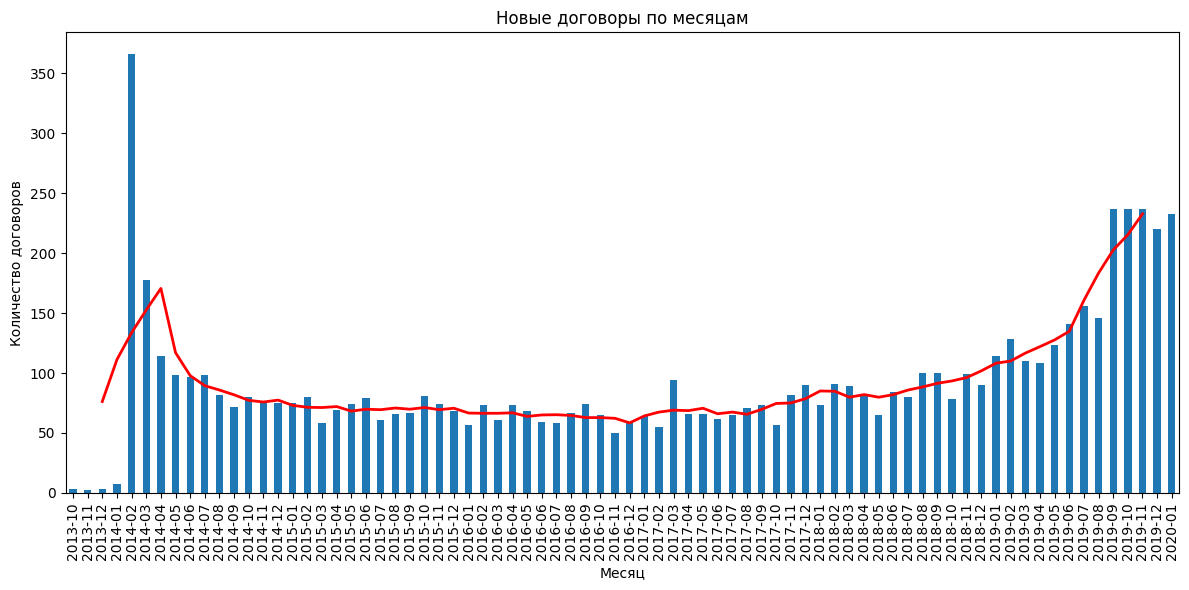

In [40]:
contract_by_month = (
    merged_df_rus
    .set_index('Дата начала договора')
    .resample('M')
    .size()
)

# Преобразуем даты в формат YYYY-MM
contract_by_month.index = contract_by_month.index.strftime('%Y-%m')

plt.figure(figsize=(12, 6))

# Бар-плот
contract_by_month.plot(kind='bar')

# Сглаживающая средняя
contract_by_month.rolling(window=5, center=True).mean().plot(
    color='red', linewidth=2, label='Скользящая средняя'
)

plt.xlabel("Месяц")
plt.ylabel("Количество договоров")
plt.title("Новые договоры по месяцам")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

В течение 2014-2017 годов количество заключенных договоров по месяцем оставалось приблизитеьно на одном уровне. В 2018 и особенно в 2019 годах наблюдается рост количества новых клиентов.

Визуализируем количество разорванных договоров по месяцам.

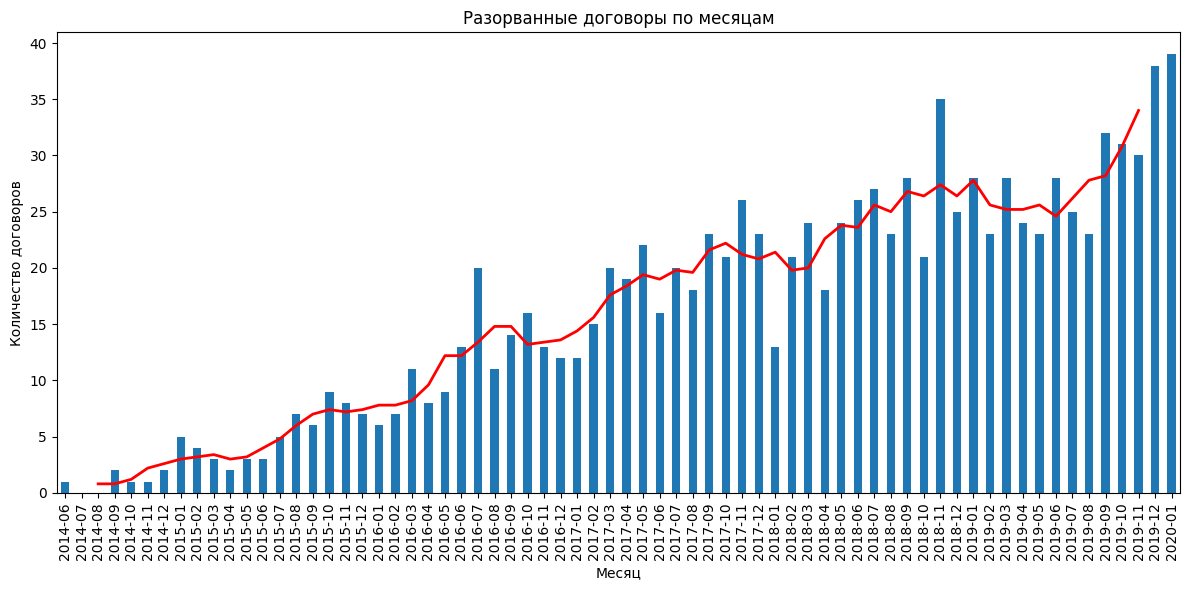

In [41]:
end_by_month = (
    merged_df_rus
    .set_index('Дата окончания договора')
    .resample('M')
    .size()
)

# Преобразуем даты в формат YYYY-MM
end_by_month.index = end_by_month.index.strftime('%Y-%m')

plt.figure(figsize=(12, 6))

end_by_month.plot(kind='bar')

end_by_month.rolling(window=5, center=True).mean().plot(
    color='red', linewidth=2
)

plt.xlabel("Месяц")
plt.ylabel("Количество договоров")
plt.title("Разорванные договоры по месяцам")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Количество разорваных контрактов линейно растет в течение всего периода наблюдений.

Построим круговую диаграмму для количества расторгнутых и действующих договоров.

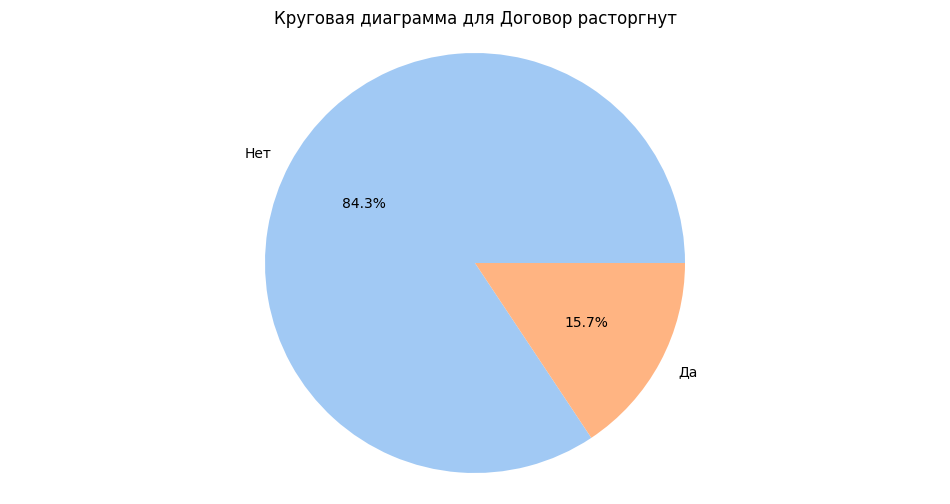

In [42]:
show_pie(merged_df_rus, 'Договор расторгнут')

15,7% договоров, заключенных с представленный период, были расторгнуты. Данные не сбалансированы по целевому признаку. При делении данных на обучающую и тестовую выборки проведем стратификацию по целевому признаку.

Посмотрим на распределение длительности контрактов до расторжения в днях.

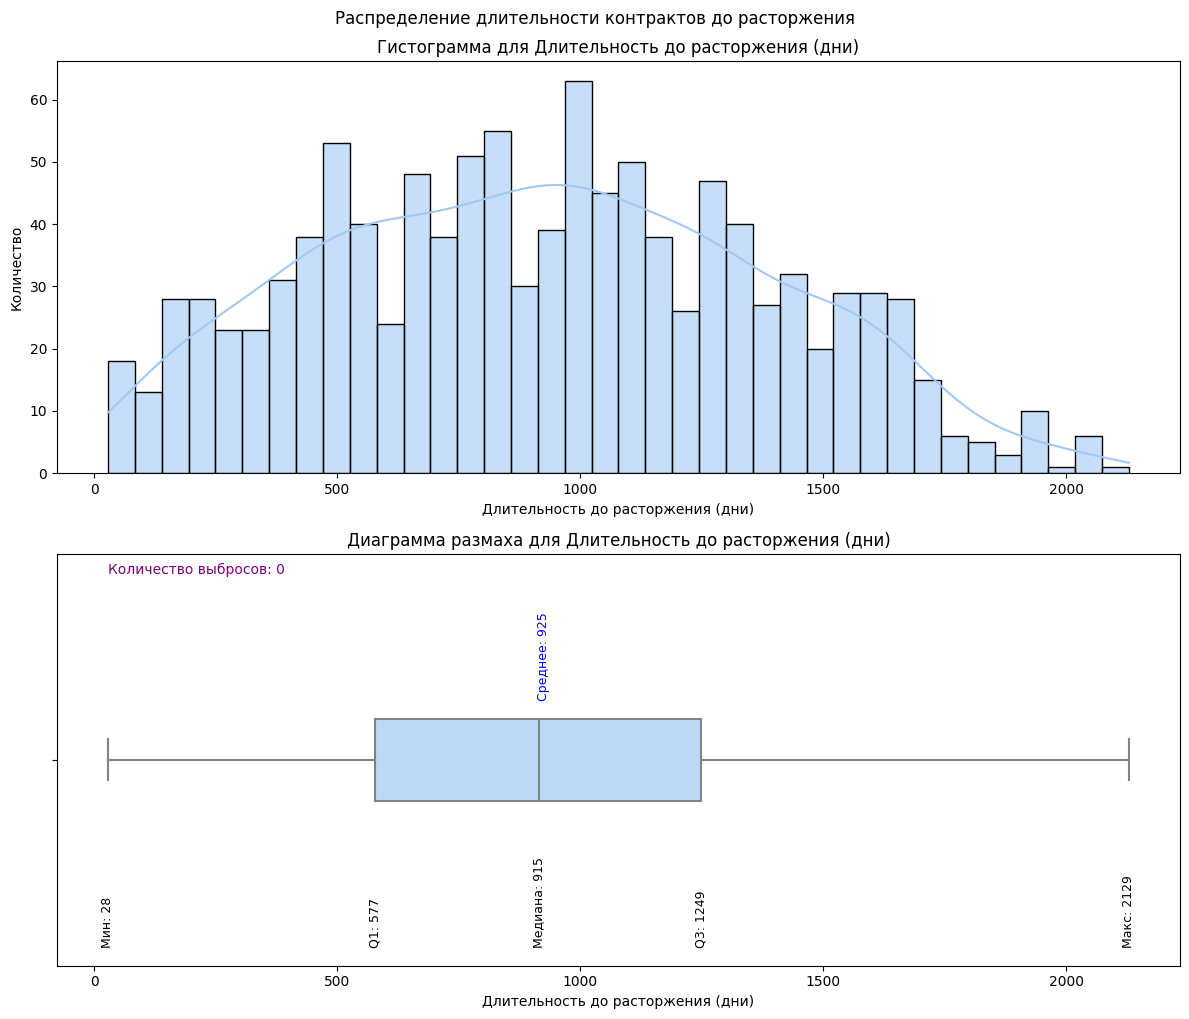

In [43]:
show_plot(merged_df_rus, 'Длительность до расторжения (дни)', type='hist', new_bins=38, new_hue=None, 
                main_title="Распределение длительности контрактов до расторжения", new_stat='count', new_common_norm=True, new_kde=True)

Гистограмма приблизитеьно имеет вид нормального распределения.<br>
Средняя длительность договора до расторжения 925 дней, медианная - 915 дней.<br>
Межквартильный размах от 577 до 1249 дней.<br>

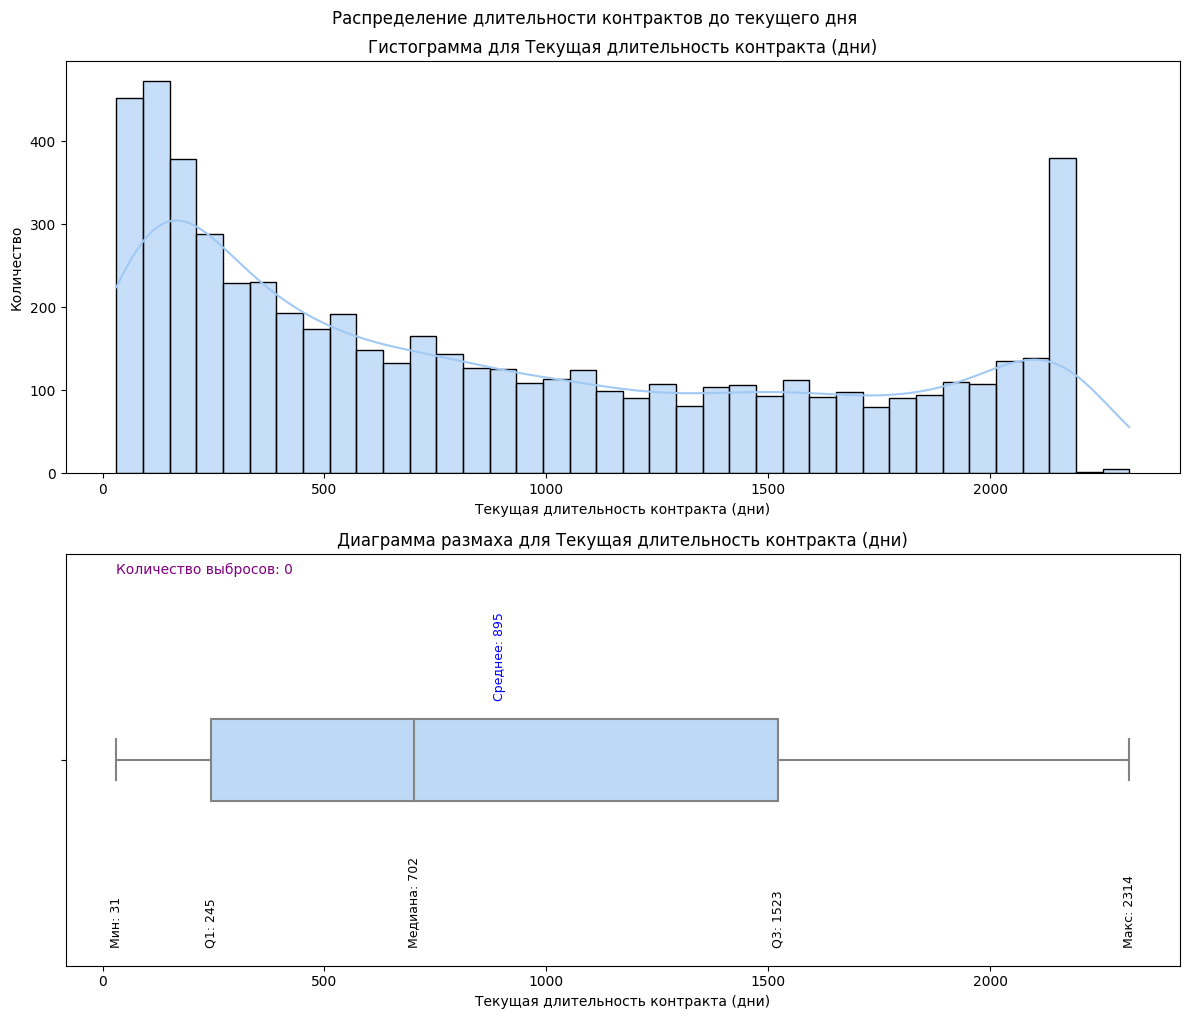

In [44]:
show_plot(merged_df_rus, 'Текущая длительность контракта (дни)', type='hist', new_bins=38, new_hue=None, 
                main_title="Распределение длительности контрактов до текущего дня", new_stat='count', new_common_norm=True, new_kde=True)

Гистограмма зеркально отражает график заключения договоров по месяцам.<br>
Средняя длительность договора 895 дней, медианная - 702 дня.<br>
Межквартильный размах от 245 до 1523 дней.<br>

Далее будем строить графики **с разбивкой по целевому признаку**, чтобы увидеть разницу в распределениях.

График распределения ежемесячных расходов.

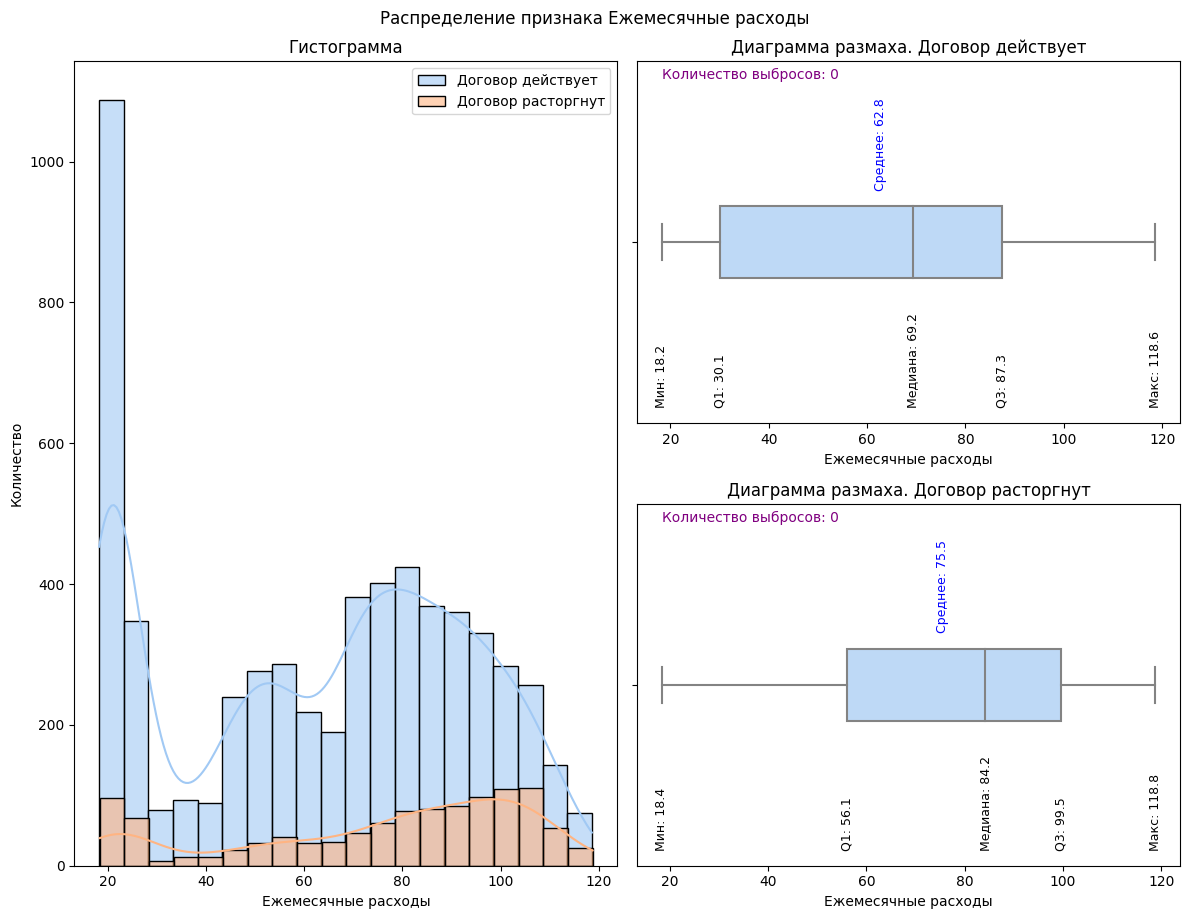

In [45]:
show_2_plots(merged_df_rus[merged_df_rus['Договор расторгнут'] == 'Нет'], merged_df_rus[merged_df_rus['Договор расторгнут'] == 'Да'], 
             'Ежемесячные расходы', type='hist', new_bins=20, df_label='Договор действует', df2_label='Договор расторгнут', 
             main_title=f'Распределение признака Ежемесячные расходы')

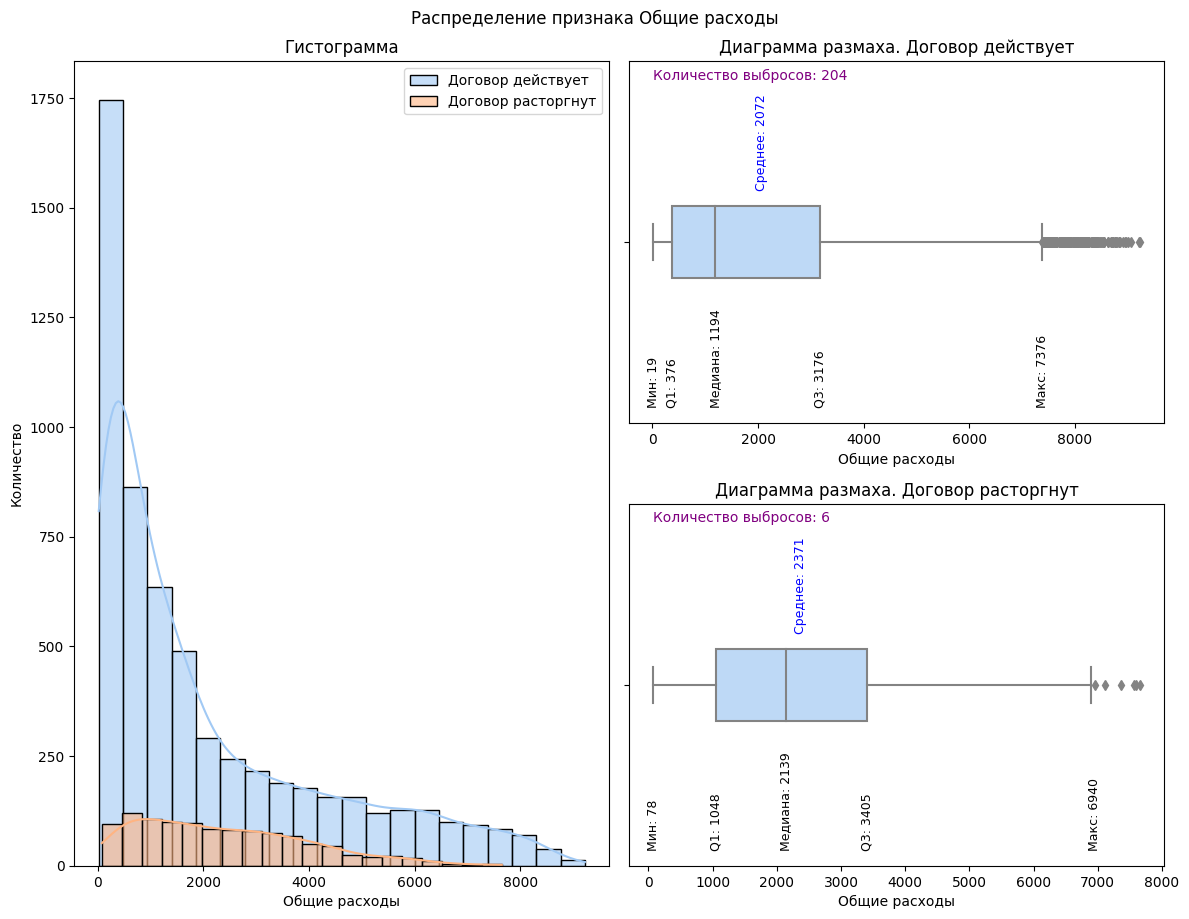

In [46]:
show_2_plots(merged_df_rus[merged_df_rus['Договор расторгнут'] == 'Нет'], merged_df_rus[merged_df_rus['Договор расторгнут'] == 'Да'], 
             'Общие расходы', type='hist', new_bins=20, df_label='Договор действует', df2_label='Договор расторгнут', 
             main_title=f'Распределение признака Общие расходы', show_outliers=False)

На графиках ежемесячных и общих расходов можно заметить, что абоненты, расторгнувшие договор, в среднем тратили больше.

Средняя сумма ежемесячных трат для действующих клиентов 62.8, медианная - 69.2.<br>
Межквартильный размах от 30.1 до 87.3.<br>

Средняя сумма ежемесячных трат для ушедших клиентов 75.5, медианная - 84.2.<br>
Межквартильный размах от 56.1 до 99.5.<br>

Средняя сумма общих трат для действующих клиентов 2072, медианная - 1194.<br>
Межквартильный размах от 376 до 3176.<br>

Средняя сумма общих трат для ушедших клиентов 2371, медианная - 2139.<br>
Межквартильный размах от 1048 до 3405.<br>

Распределение для количества доплнительных услуг.

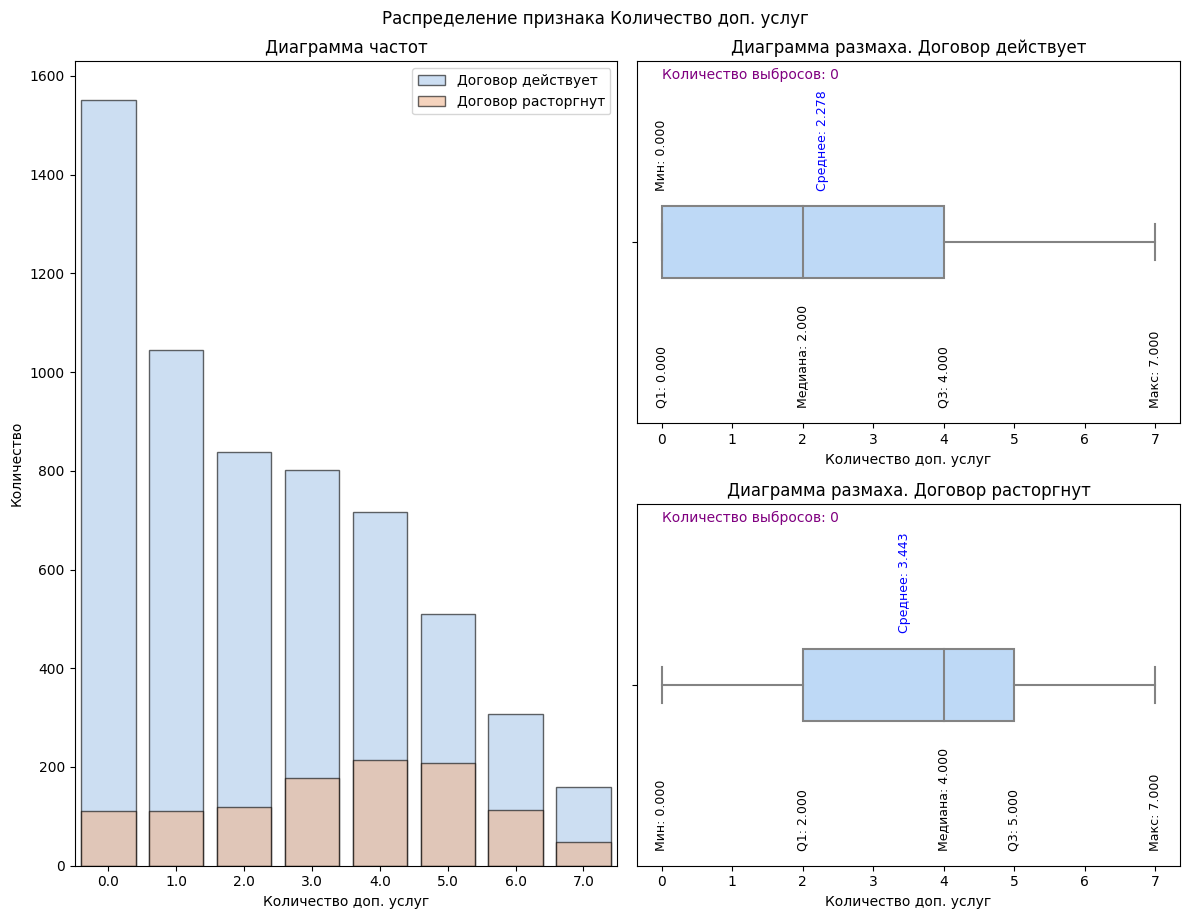

In [47]:
show_2_plots(merged_df_rus[merged_df_rus['Договор расторгнут'] == 'Нет'], merged_df_rus[merged_df_rus['Договор расторгнут'] == 'Да'], 
             'Количество доп. услуг', type='bars', df_label='Договор действует', df2_label='Договор расторгнут', 
             main_title=f'Распределение признака Количество доп. услуг', show_outliers=False)

Клиенты, расторгнувшие договор, использовали большее количество дополнительных услуг. <br>
Нужно будет проверить данный признак на мультиколлинеарность с тратами клиентов.

Визуализируем категориальные признаки.

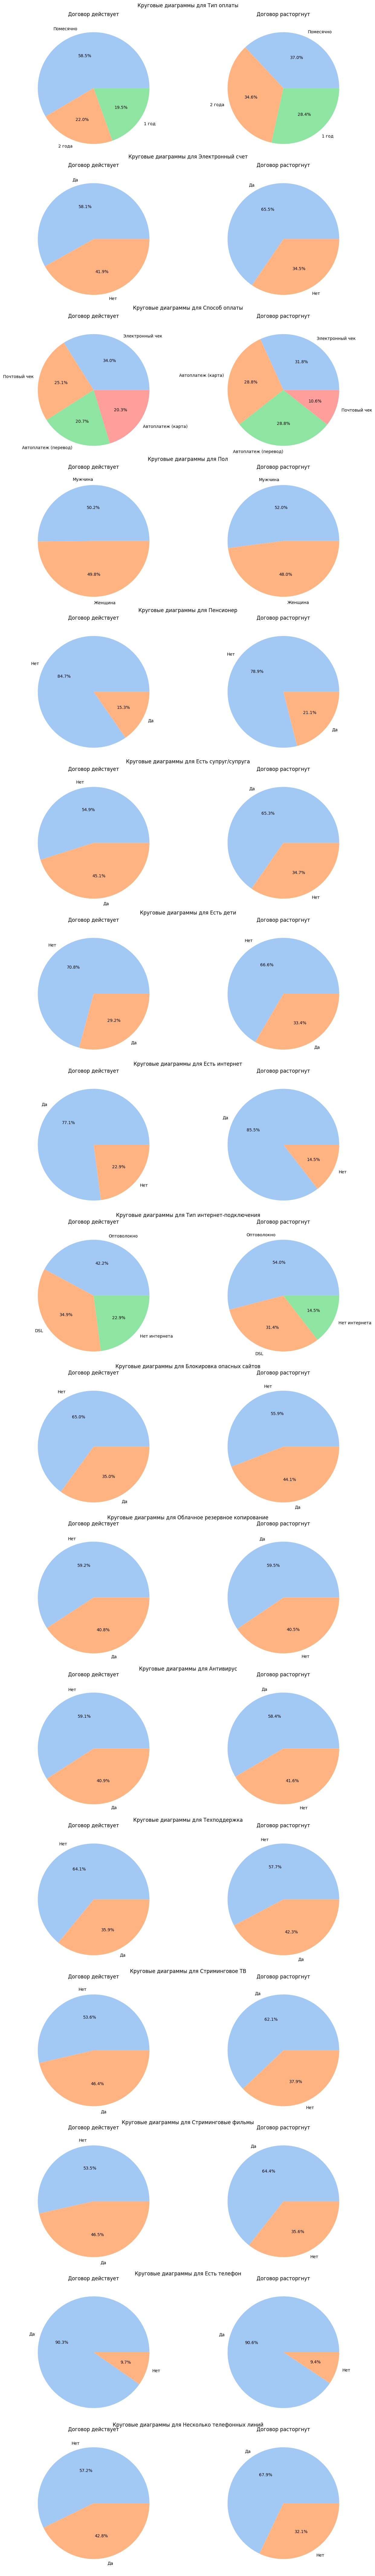

In [48]:
cat_cols = [
    "Тип оплаты",
    "Электронный счет",
    "Способ оплаты",
    "Пол",
    "Пенсионер",
    "Есть супруг/супруга",
    "Есть дети",
    "Есть интернет",
    "Тип интернет-подключения",
    "Блокировка опасных сайтов",
    "Облачное резервное копирование",
    "Антивирус",
    "Техподдержка",
    "Стриминговое ТВ",
    "Стриминговые фильмы",
    "Есть телефон",
    "Несколько телефонных линий"
]

merged_df_rus_temp = merged_df_rus.replace("Не применимо", pd.NA)
merged_df_rus_temp = merged_df_rus_temp.replace("Нет интернета", pd.NA)

show_2_pies(merged_df_rus_temp[merged_df_rus_temp['Договор расторгнут'] == 'Нет'], 
            merged_df_rus_temp[merged_df_rus_temp['Договор расторгнут'] == 'Да'], 
            cat_cols, df_label='Договор действует', df2_label='Договор расторгнут')

Для большинста признаков нет явной разницы в распределении для действующих и ушедших клиентов. 

Можно заметить, что действующие клиенты чаще платят помесячно и используют выделенную линию технической поддержки.

**Общий портрет ушедшего клиента:** <br>
Не пенсионер в браке, который пользуется высокоскоростным (оптоволоконным) интернетом, оплачивет услуги раз в один или два года, платеж чаще автоматический, подключает дополнительные подписки на стриминговые фильмы и ТВ и использует несколько телефонных линий.

**3.3 Корреляционный анализ**

**Посчитаем матрицу корреляций Phik**

In [49]:
numeric_cols = [
    'Ежемесячные расходы',
    'Общие расходы',
    'Количество доп. услуг',
    'Длительность до расторжения (дни)',
    'Текущая длительность контракта (дни)'
]

# Вычисляем матрицу корреляции Phik
corr_matrix_phik = merged_df_rus.drop(columns=['ID клиента', 'Дата начала договора']).phik_matrix(interval_cols=numeric_cols)

# Выводим матрицу
corr_matrix_phik

,Дата окончания договора,Тип оплаты,Электронный счет,Способ оплаты,Ежемесячные расходы,Общие расходы,Пол,Пенсионер,Есть супруг/супруга,Есть дети,Тип интернет-подключения,Блокировка опасных сайтов,Облачное резервное копирование,Антивирус,Техподдержка,Стриминговое ТВ,Стриминговые фильмы,Несколько телефонных линий,Договор расторгнут,Есть интернет,Есть телефон,Количество доп. услуг,Длительность до расторжения (дни),Текущая длительность контракта (дни),Дней с момента заключения договора,Длительность контракта,Длительность контракта (месяцев),Длительность контракта (месяцев) * Месячный платеж
Дата окончания договора,1.000000,0.398284,0.065379,0.120097,0.000000,0.051673,0.046046,0.054282,0.086772,0.076916,0.000000,0.251298,0.304121,0.282602,0.248721,0.149315,0.090692,0.142053,NaN,0.120729,0.000000,0.253846,0.612646,NaN,0.000000,0.957252,0.957252,0.000000
Тип оплаты,0.398284,1.000000,0.106151,0.277528,0.388379,0.470700,0.000000,0.085800,0.179294,0.146126,0.503776,0.636227,0.580887,0.630968,0.671126,0.548723,0.553780,0.244802,0.094622,0.146149,0.000000,0.456647,0.345464,0.675734,0.765275,0.763702,0.763702,0.903821
Электронный счет,0.065379,0.106151,1.000000,0.368945,0.467518,0.202168,0.000000,0.241715,0.010489,0.170650,0.231145,0.208084,0.195065,0.195398,0.200363,0.204617,0.202005,0.100063,0.082789,0.481811,0.017239,0.342550,0.000000,0.000000,0.078664,0.073812,0.073812,0.519333
Способ оплаты,0.120097,0.277528,0.368945,1.000000,0.398860,0.334563,0.000000,0.291989,0.244661,0.222859,0.323013,0.314888,0.292646,0.297187,0.316805,0.283902,0.284844,0.174953,0.214300,0.533446,0.000000,0.462537,0.164580,0.367967,0.467586,0.464362,0.464362,0.712780
Ежемесячные расходы,0.000000,0.388379,0.467518,0.398860,1.000000,0.711148,0.006724,0.304252,0.204269,0.182129,0.918983,0.812550,0.818868,0.827409,0.816587,0.864786,0.863569,0.710410,0.225467,0.998682,0.831671,0.781658,0.091549,0.431081,0.421649,0.426788,0.426788,0.999173
Общие расходы,0.051673,0.470700,0.202168,0.334563,0.711148,1.000000,0.000000,0.136856,0.383135,0.085809,0.489363,0.516500,0.550605,0.558748,0.527978,0.555663,0.554074,0.467826,0.303758,0.548179,0.159394,0.621985,0.711277,0.843112,0.773731,0.838068,0.838068,0.999201
Пол,0.046046,0.000000,0.000000,0.000000,0.006724,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.008800,0.000000,0.000000,0.000000,0.012534,0.000000,0.018540,0.000000,0.000000,0.328678
Пенсионер,0.054282,0.085800,0.241715,0.291989,0.304252,0.136856,0.000000,1.000000,0.018075,0.323629,0.160452,0.127108,0.109855,0.110029,0.135073,0.111610,0.113611,0.087978,0.085708,0.281515,0.000000,0.181273,0.000000,0.025962,0.049516,0.142912,0.142912,0.703289
Есть супруг/супруга,0.086772,0.179294,0.010489,0.244661,0.204269,0.383135,0.000000,0.018075,1.000000,0.651635,0.000000,0.091140,0.091990,0.099685,0.076244,0.081850,0.077710,0.086495,0.227597,0.000000,0.021002,0.304061,0.108645,0.484672,0.485513,0.463122,0.463122,0.523496
Есть дети,0.076916,0.146126,0.170650,0.222859,0.182129,0.085809,0.000000,0.323629,0.651635,1.000000,0.107328,0.116236,0.096785,0.093606,0.108747,0.087232,0.083895,0.011135,0.048710,0.214311,0.000000,0.121221,0.046851,0.211319,0.201169,0.213038,0.213038,0.323607


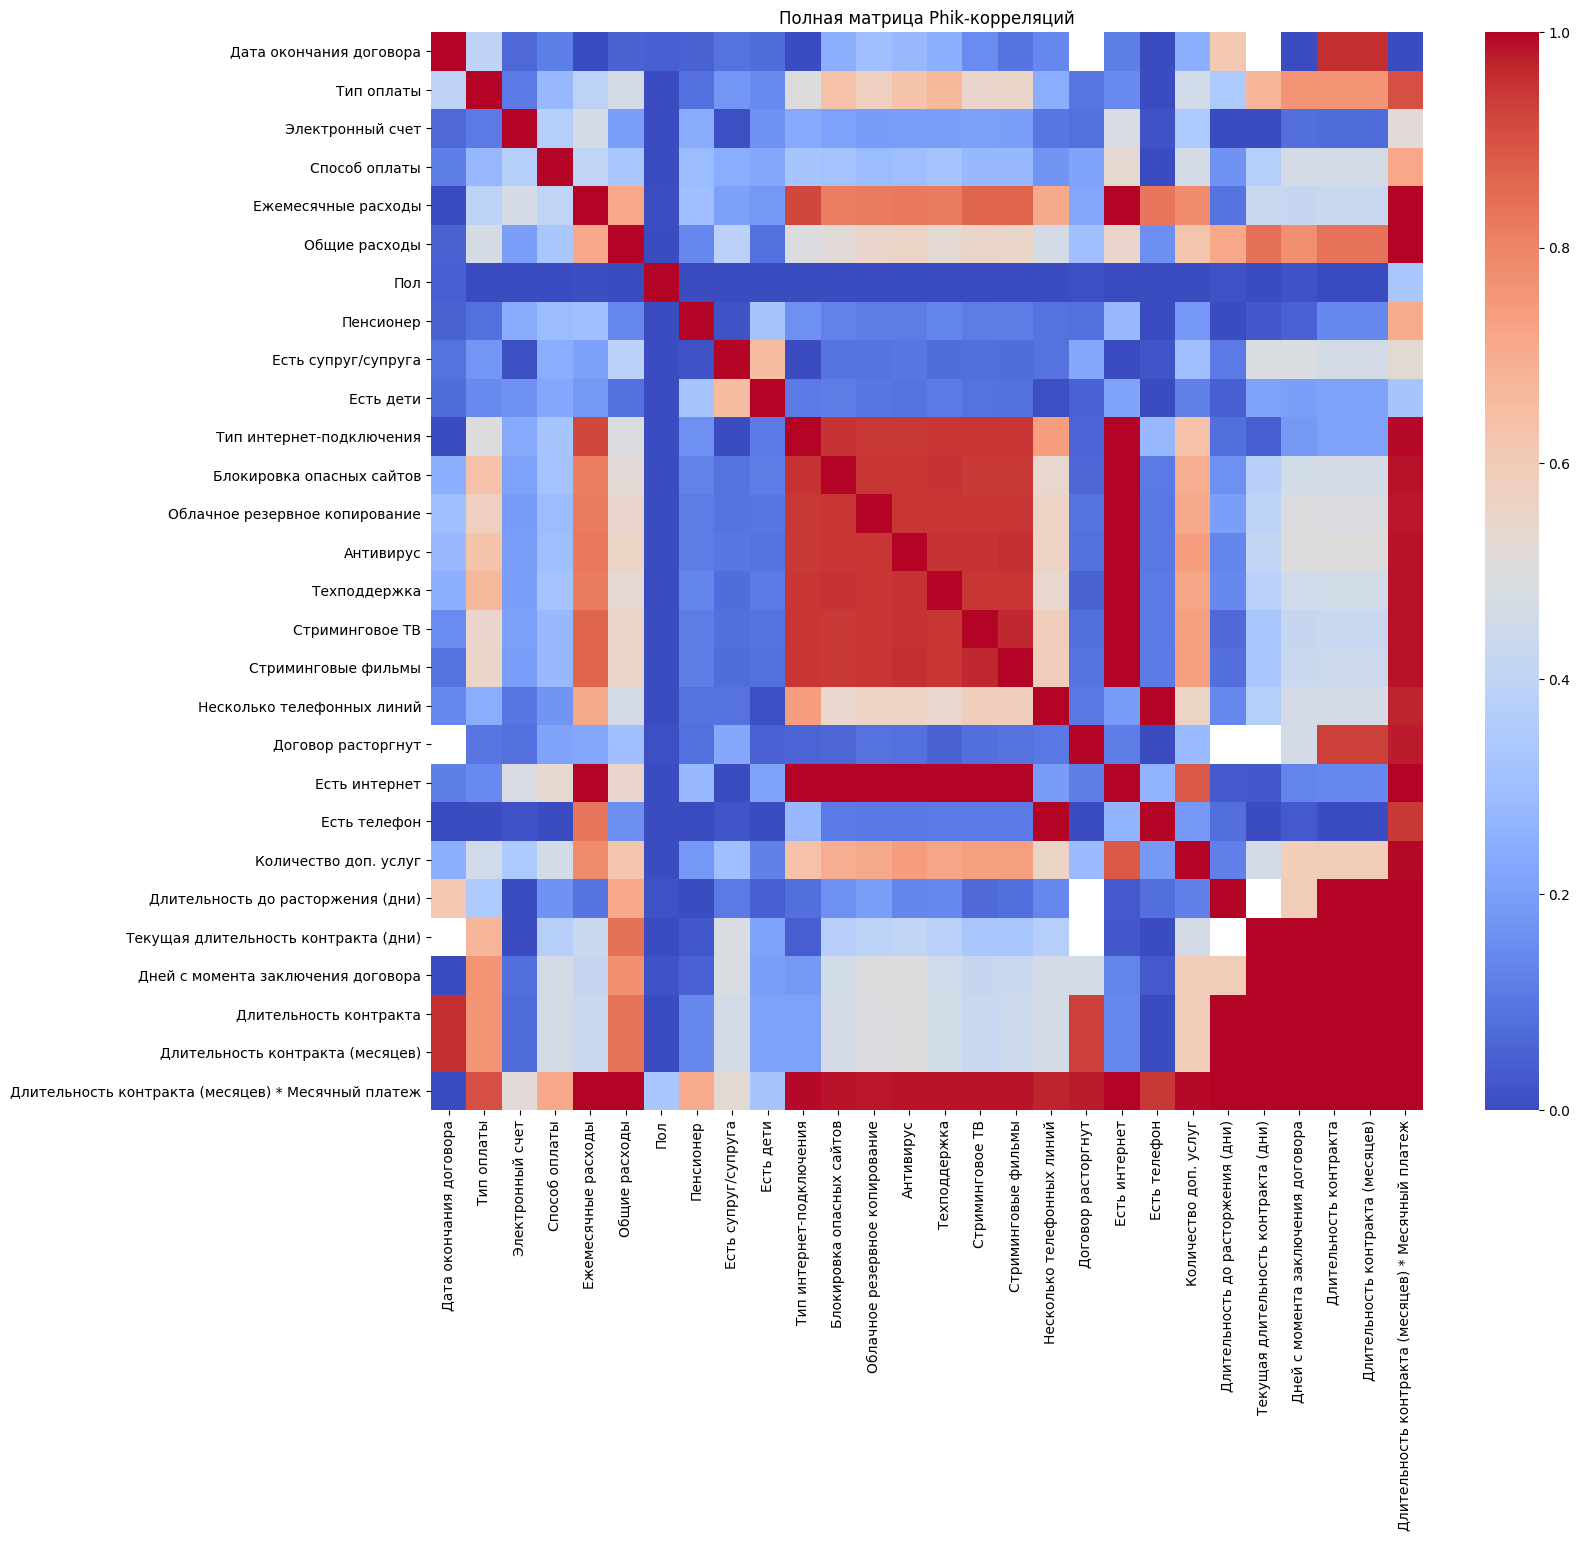

In [50]:
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix_phik, annot=False, cmap="coolwarm")
plt.title("Полная матрица Phik-корреляций")
plt.show()

Текстовое описание весьма высоких корреляций:

In [51]:
print_corr_levels(corr_matrix_phik, threshold=0.9)

[('Весьма высокая корреляция между Блокировка опасных сайтов и Есть интернет:',
  1.0),
 ('Весьма высокая корреляция между Антивирус и Есть интернет:', 1.0),
 ('Весьма высокая корреляция между Есть интернет и Тип интернет-подключения:',
  1.0),
 ('Весьма высокая корреляция между Есть интернет и Облачное резервное копирование:',
  1.0),
 ('Весьма высокая корреляция между Есть интернет и Техподдержка:', 1.0),
 ('Весьма высокая корреляция между Есть интернет и Стриминговое ТВ:', 1.0),
 ('Весьма высокая корреляция между Есть интернет и Стриминговые фильмы:', 1.0),
 ('Весьма высокая корреляция между Есть телефон и Несколько телефонных линий:',
  1.0),
 ('Весьма высокая корреляция между Длительность до расторжения (дни) и Длительность контракта:',
  1.0),
 ('Весьма высокая корреляция между Длительность до расторжения (дни) и Длительность контракта (месяцев):',
  1.0),
 ('Весьма высокая корреляция между Длительность до расторжения (дни) и Длительность контракта (месяцев) * Месячный платеж:',


Текстовое описание корреляций целевого признака:

In [52]:
print_corr_levels_target(corr_matrix_phik, threshold=0.1)

[('Весьма высокая корреляция между Договор расторгнут и Длительность контракта (месяцев) * Месячный платеж:',
  0.978),
 ('Весьма высокая корреляция между Договор расторгнут и Длительность контракта:',
  0.933),
 ('Весьма высокая корреляция между Договор расторгнут и Длительность контракта (месяцев):',
  0.933),
 ('Умеренная корреляция между Договор расторгнут и Дней с момента заключения договора:',
  0.462),
 ('Умеренная корреляция между Договор расторгнут и Общие расходы:', 0.304),
 ('Слабая корреляция между Договор расторгнут и Количество доп. услуг:',
  0.286),
 ('Слабая корреляция между Договор расторгнут и Есть супруг/супруга:', 0.228),
 ('Слабая корреляция между Договор расторгнут и Ежемесячные расходы:', 0.225),
 ('Слабая корреляция между Договор расторгнут и Способ оплаты:', 0.214),
 ('Слабая корреляция между Договор расторгнут и Есть интернет:', 0.114),
 ('Слабая корреляция между Договор расторгнут и Несколько телефонных линий:',
  0.105)]

Имеется мультиколлинеарность между стобцами с дополнительными интернет услугами. <br>
Целевой признак не коррелирует с каждым из этих признаков по отдельности, но имеет слабую корреляцию с общим количеством доп. услуг.<br>

Целевой признак имеет корреляцию с Длительностью контракта, Количеством дней с момента заключения договора, Общими расходами, Количеством доп. услуг, Наличием супруга/супруги, Ежемесячными расходами, Способом оплаты, Наличием интернета и Наличием нескольких телефонных линий.

Есть признаки мультиколлинеарности между ежемесячными расходами и наличием интернета. Но убирать из обучающей выборки один из признаков не будем. так как целевой признак мало коррелирует с другими признаками, и исключение данных может только ухудшить обучаемую модель.

**Посмотрим на связь общих трат и длительности  договора умноженного на ежемесячную плату.**

In [53]:
corr = merged_df['contract_duration (months) * monthly_charges'].corr(merged_df['total_charges'])
print(f"Корреляция Пирсона для общих трат и ежемесячных трат умноженных на длительность договора: {corr:.4f}")

Корреляция Пирсона для общих трат и ежемесячных трат умноженных на длительность договора: 0.9989


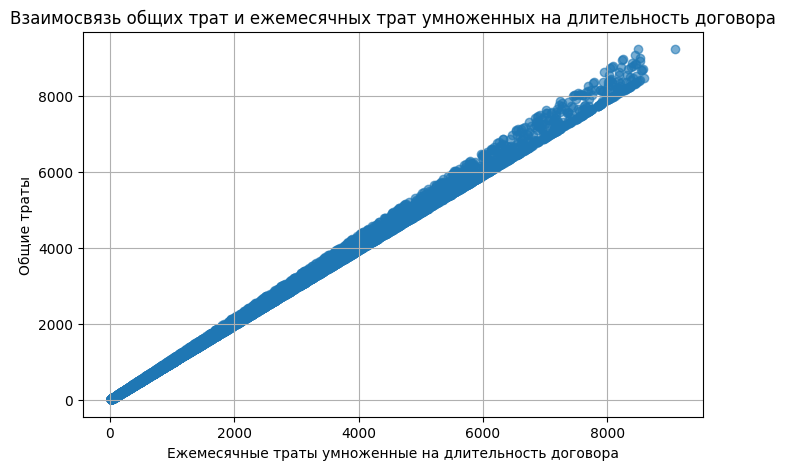

In [54]:
plt.figure(figsize=(8,5))
plt.scatter(
    merged_df['contract_duration (months) * monthly_charges'], 
    merged_df['total_charges'],
    alpha=0.6
)
plt.xlabel('Ежемесячные траты умноженные на длительность договора')
plt.ylabel('Общие траты')
plt.title('Взаимосвязь общих трат и ежемесячных трат умноженных на длительность договора')
plt.grid(True)
plt.show()

**Сравним со связью общих трат и ежемесячных трат умноженных на период с момента подписания договора.**

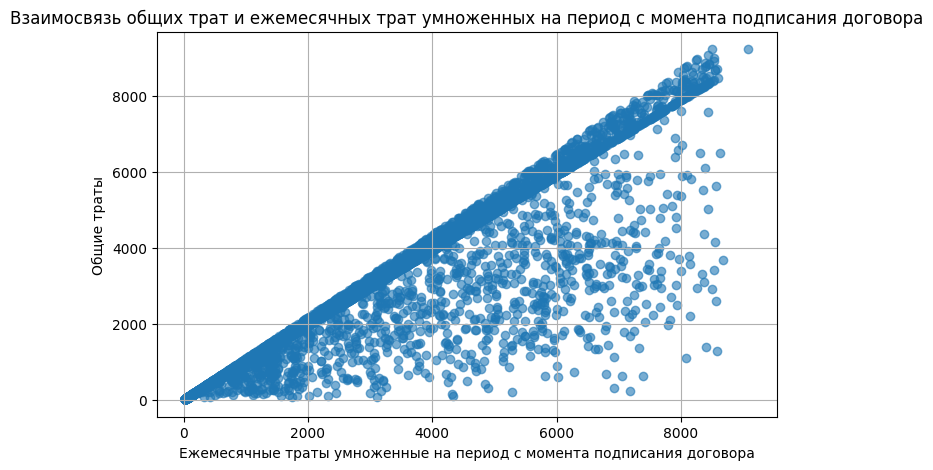

In [55]:
plt.figure(figsize=(8,5))
plt.scatter(
    merged_df['days_since_begin_date']/30 * merged_df['monthly_charges'], 
    merged_df['total_charges'],
    alpha=0.6
)
plt.xlabel('Ежемесячные траты умноженные на период с момента подписания договора')
plt.ylabel('Общие траты')
plt.title('Взаимосвязь общих трат и ежемесячных трат умноженных на период с момента подписания договора')
plt.grid(True)
plt.show()

Общие траты абонента равны ежемесячным тратам умноженным на длительность договора. Можно заметить, что ежемесячные траты не менялись в течение периода наблюдений.<br>
Использование 'days_since_begin_date' приведет к косвенной утечке признака, потому что всё, что не лежит на полученной прямой - это ушедшие клиенты.

**3.4 Оценка связи признаков с оттоком клиентов**

Для понимания того, какие признаки сильнее всего связаны с уходом кдиентов, оценим связь входных признаков с таргетом.<br>
Для ценки используем функцию mutual_info_classif из библиотеки sklearn.feature_selection.

In [56]:
X = merged_df_rus.drop(['ID клиента',
                        'Дата начала договора',
                        'Дата окончания договора', 
                        'Длительность до расторжения (дни)', 
                        'Договор расторгнут', 
                        'Текущая длительность контракта (дни)'], axis=1)

y = merged_df_rus['Договор расторгнут']

In [57]:
for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col])

In [58]:
mi = mutual_info_classif(X, y, random_state=RANDOM_STATE)

mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)
print(mi_series)

Длительность контракта (месяцев)                      0.250877
Длительность контракта                                0.246718
Дней с момента заключения договора                    0.073970
Длительность контракта (месяцев) * Месячный платеж    0.043612
Общие расходы                                         0.036344
Количество доп. услуг                                 0.019078
Тип оплаты                                            0.019051
Несколько телефонных линий                            0.015858
Способ оплаты                                         0.015769
Стриминговые фильмы                                   0.015168
Блокировка опасных сайтов                             0.014582
Есть супруг/супруга                                   0.014060
Антивирус                                             0.012169
Облачное резервное копирование                        0.010526
Ежемесячные расходы                                   0.008920
Пол                                                   0

**Промежуточный итог:**

В ходе исследовательского анализа была изучена статистическая информация данных, данные визуализированы, посчитаны корреляции между признаками.

По результатам анализа можно выделить признаки, которые сильнее всего коррелируют с целевым признаком: Дней с момента заключения договора, Общие расходы, Количество доп. услуг, Есть супруг/супруга, Ежемесячные расходы, Способ оплаты, Есть интернет, Несколько телефонных линий. 

Также по результатам оценки диаграмм и оценки связи признаков можно добавить в обучающий датафрейм признаки: Пенсионер, Тип интернет-подключения, Тип оплаты, Стриминговые фильмы, Блокировка опасных сайтов, Техподдержка.

<a class='anchor' id="link4"></a>
## 4 Обучение моделей

**4.1 Подготовка данных к обучению**

Подготовим обучающий датафрейм.

In [59]:
"""
prepared_df = merged_df[[
    'days_since_begin_date', # Дней с момента заключения договора
    'total_charges',         # Общие расходы
    'num_services',          # Количество доп. услуг
    'partner',               # Есть супруг/супруга
    'monthly_charges',       # Ежемесячные расходы
    'payment_method',        # Способ оплаты
    'has_internet',          # Есть интернет
    'multiple_lines',        # Несколько телефонных линий
    'senior_citizen',        # Пенсионер
    'internet_service',      # Тип интернет-подключения
    'type',                  # Тип оплаты
    'streaming_movies',      # Стриминговые фильмы
    'online_security',       # Блокировка опасных сайтов
    'tech_support'           # Техподдержка
]].copy()

target = merged_df['end']
""";

In [60]:
prepared_df = merged_df[[
    'contract_duration',     # Длительность договора
    'num_services',          # Количество доп. услуг
    'partner',               # Есть супруг/супруга
    'monthly_charges',       # Ежемесячные расходы
    'payment_method',        # Способ оплаты
    'has_internet',          # Есть интернет
    'multiple_lines',        # Несколько телефонных линий
    'senior_citizen',        # Пенсионер
    'internet_service',      # Тип интернет-подключения
    'type',                  # Тип оплаты
    'streaming_movies',      # Стриминговые фильмы
    'online_security',       # Блокировка опасных сайтов
    'tech_support'           # Техподдержка
]].copy()

target = merged_df['end']

Разделим данные на обучающую и тестовую выборки.

In [61]:
X = prepared_df

le = LabelEncoder()
y = le.fit_transform(target)

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE, 
    stratify=y
)

Создаем препроцессор для обработки входных признаков.

In [62]:
numeric_features = ['contract_duration', 'num_services', 'monthly_charges']
categorical_features = ['type', 'payment_method', 'internet_service', 'multiple_lines', 
                        'partner', 'senior_citizen', 'streaming_movies', 'online_security', 'tech_support', 'has_internet']

numeric_transformer = StandardScaler()

categorical_transformer = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

Данные готовы к обучению моделей.

**4.2 Обучение RandomForestClassifier**

In [63]:
# Создаем пайплайн с препроцессором и моделью
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE))
])

# Задаем сетку гиперпараметров для подбора
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

# Целевой признак не сбалансирован, поэтому используем StratifiedKFold для кросс-валидации
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# GridSearchCV с оценкой по ROC-AUC
grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

# Обучение
grid_rf.fit(X_train, y_train);

Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [64]:
# Лучшая модель и ROC-AUC на кросс-валидации
best_rf = grid_rf.best_estimator_

print('Лучшие параметры:', grid_rf.best_params_)
print(f'\nМетрика ROC-AUC для лучшей модели RandomForestClassifier: {grid_rf.best_score_:.3f}\n') 

Лучшие параметры: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Метрика ROC-AUC для лучшей модели RandomForestClassifier: 0.828



**4.3 Обучение LGBMClassifier**

In [65]:
# Создаём пайплайн с препроцессингом и моделью
lgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(random_state=RANDOM_STATE))
])

# Задаём сетку гиперпараметров для поиска
param_grid_lgbm = {
    'classifier__n_estimators': [100, 200],         # количество деревьев
    'classifier__max_depth': [6, 10],               # максимальная глубина дерева
    'classifier__learning_rate': [0.05, 0.1]       # скорость обучения
}

# StratifiedKFold для кросс-валидации
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Создаём GridSearchCV
grid_lgbm = GridSearchCV(
    estimator=lgbm_pipeline,
    param_grid=param_grid_lgbm,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

# Запускаем обучение
grid_lgbm.fit(X_train, y_train);

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[LightGBM] [Info] Number of positive: 826, number of negative: 4448
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 466
[LightGBM] [Info] Number of data points in the train set: 5274, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.156617 -> initscore=-1.683615
[LightGBM] [Info] Start training from score -1.683615
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [

In [66]:
# Лучшая модель и ROC-AUC на кросс-валидации
best_lgbm = grid_lgbm.best_estimator_

print('Лучшие параметры:', grid_lgbm.best_params_)
print(f'\nМетрика ROC-AUC для лучшей модели LGBMClassifier: {grid_lgbm.best_score_:.3f}\n') 

Лучшие параметры: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 10, 'classifier__n_estimators': 200}

Метрика ROC-AUC для лучшей модели LGBMClassifier: 0.889



**4.4 Обучение нейросети KerasClassifier**

In [67]:
# Создание Keras-модели
def create_nn_model(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_dim=input_dim),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )
    return model

# Получаем размерность входа
X_train_transformed = preprocessor.fit_transform(X_train)
input_dim = X_train_transformed.shape[1]

# Создаём KerasClassifier
nn_classifier = KerasClassifier(
    model=create_nn_model,
    model__input_dim=input_dim,
    epochs=200,
    batch_size=64,
    validation_split=0.2,
    verbose=1,
    callbacks=[
        EarlyStopping(
            monitor='val_auc',
            patience=15,
            min_delta=0.001,
            mode='max',
            restore_best_weights=True,
            verbose=1
        )
    ],
    random_state=RANDOM_STATE
)

# Pipeline
nn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', nn_classifier)
])

# Обучаем
nn_pipeline.fit(X_train, y_train);

Epoch 1/200
66/66 [==============================] - 1s 6ms/step - loss: 0.4354 - auc: 0.6012 - val_loss: 0.3980 - val_auc: 0.7185
Epoch 2/200
66/66 [==============================] - 0s 2ms/step - loss: 0.3878 - auc: 0.7283 - val_loss: 0.3658 - val_auc: 0.7901
Epoch 3/200
66/66 [==============================] - 0s 2ms/step - loss: 0.3640 - auc: 0.7774 - val_loss: 0.3497 - val_auc: 0.8124
Epoch 4/200
66/66 [==============================] - 0s 2ms/step - loss: 0.3548 - auc: 0.7933 - val_loss: 0.3400 - val_auc: 0.8218
Epoch 5/200
66/66 [==============================] - 0s 3ms/step - loss: 0.3453 - auc: 0.8073 - val_loss: 0.3356 - val_auc: 0.8234
Epoch 6/200
66/66 [==============================] - 0s 3ms/step - loss: 0.3415 - auc: 0.8108 - val_loss: 0.3363 - val_auc: 0.8269
Epoch 7/200
66/66 [==============================] - 0s 2ms/step - loss: 0.3358 - auc: 0.8205 - val_loss: 0.3343 - val_auc: 0.8255
Epoch 8/200
66/66 [==============================] - 0s 2ms/step - loss: 0.3322 - a

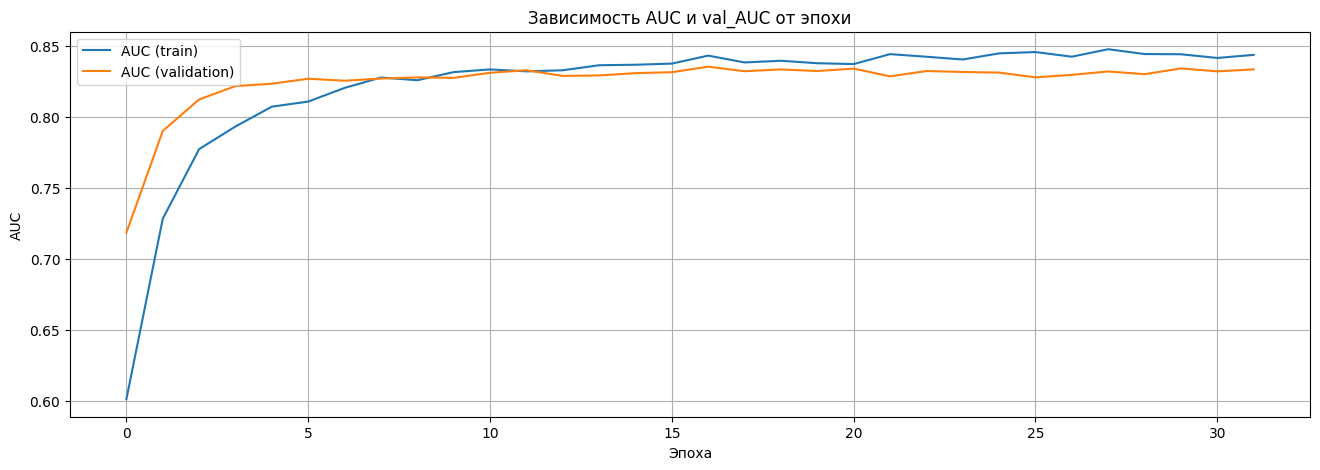

In [68]:
# История обучения
hist = nn_pipeline.named_steps["classifier"].history_
train_auc = hist['auc']
val_auc   = hist['val_auc']

# График
plt.figure(figsize=(16,5))
plt.plot(train_auc, label="AUC (train)")
plt.plot(val_auc,   label="AUC (validation)")
plt.xlabel("Эпоха")
plt.ylabel("AUC")
plt.title("Зависимость AUC и val_AUC от эпохи")
plt.legend()
plt.grid(True)
plt.show()

In [69]:
# Лучшее значение val_AUC
best_val_auc = max(hist['val_auc'])
print(f'Лучшее ROC-AUC нейросети во время обучения: {best_val_auc:.4f}')

Лучшее ROC-AUC нейросети во время обучения: 0.8354


**Промежуточный итог**

Были построены и обучены три модели: RandomForestClassifier, LGBMClassifier и нейросеть KerasClassifier. 

Лучшую метрику при обучении показала LGBMClassifier.

<a class='anchor' id="link5"></a>
## 5 Оценка качества модели

**5.1 Оценка на тестовой выборке**

Проверим качество лучшей модели LGBMClassifier на тестовой выборке.

In [70]:
y_pred_proba = grid_lgbm.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC LGBMClassifier на тестовой выборке: {roc_auc:.3f}")

ROC-AUC LGBMClassifier на тестовой выборке: 0.908


Лучшая модель выполняет целевой показатель с метрикой ROC-AUC на тестовой выборке: 0.908

**5.2 Матрица ошибок**

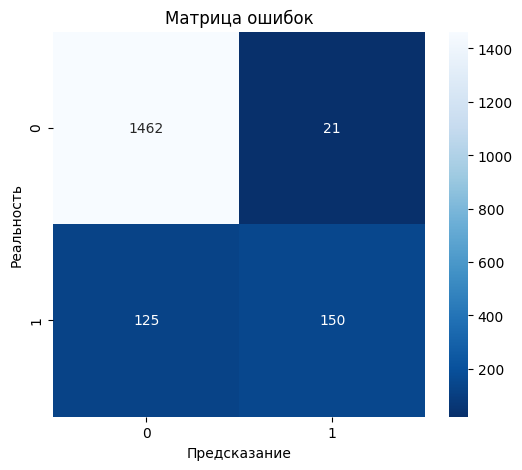

Accuracy = 0.92
Precision = 0.88
Recall = 0.55


In [71]:
# Предсказания классов
y_pred = grid_lgbm.predict(X_test)

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)

# Визуализация матрицы ошибок
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r')
plt.ylabel('Реальность')
plt.xlabel('Предсказание')
plt.title('Матрица ошибок')
plt.show()

# Основные метрики
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print('Accuracy =', round(accuracy, 2))
print('Precision =', round(precision, 2))
print('Recall =', round(recall, 2))

Модель имеет высокую точность, у нее только 12% ложноположительных срабатываний. <br> 
Доля правильных предсказаний модели LGBMClassifier достигает 92%. <br>
Однако модель нашла только 55% всех клиентов, которые расторгнут договор.

**5.3 Сравнение с DummyClassifier**

Сравним предсказания лучших моделей с моделью, которая предсказывает классы случайным образом с сохранением пропорций в распределении целевого признака.

In [72]:
# Создаём DummyClassifier
dummy = DummyClassifier(strategy='stratified')
dummy.fit(X_train, y_train)

# Предсказания
y_pred_dummy = dummy.predict(X_test)
y_pred_proba_dummy = dummy.predict_proba(X_test)[:, 1]

# Метрики
roc_auc_dummy = roc_auc_score(y_test, y_pred_proba_dummy)
print('ROC-AUC DummyClassifier =', round(roc_auc_dummy, 3))

ROC-AUC DummyClassifier = 0.496


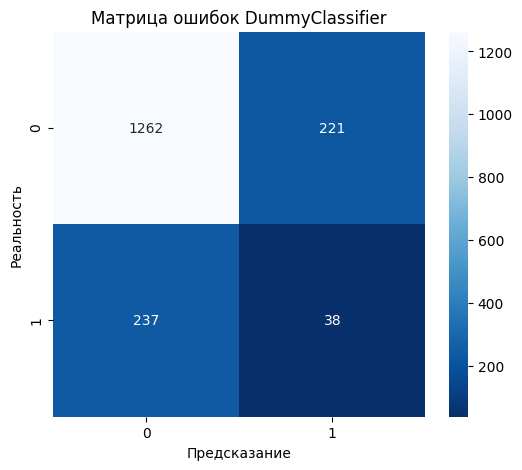

Accuracy DummyClassifier = 0.74
Precision DummyClassifier = 0.15
Recall DummyClassifier = 0.14


In [73]:
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_dummy)

# Визуализация матрицы ошибок
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r')
plt.ylabel('Реальность')
plt.xlabel('Предсказание')
plt.title('Матрица ошибок DummyClassifier')
plt.show()

# Основные метрики
accuracy = accuracy_score(y_test, y_pred_dummy)
precision = precision_score(y_test, y_pred_dummy)
recall = recall_score(y_test, y_pred_dummy)

print('Accuracy DummyClassifier =', round(accuracy, 2))
print('Precision DummyClassifier =', round(precision, 2))
print('Recall DummyClassifier =', round(recall, 2))

Метрики DummyClassifier сильно хуже метрик лучшей модели.

**Промежуточный итог:**

LGBMClassifier показывает хорошую предсказательную способность. Целевая мерика ROC-AUC выполняется.
Модель редко ошибается, однако из-за дисбаланса классов модель находит только 55% тех клиентов, которые готовы разорвать договор.
Эту метрику можно увеличить, изменив порог предсказаний. Но это приведет к росту количества ложноположительных срабатываний.

<a class='anchor' id="link6"></a>
## 6 Оценка важности признаков

In [74]:
# Подготовим модель и данные
best_pipeline = grid_lgbm.best_estimator_
model = best_pipeline.named_steps['classifier']
X_train_encoded = best_pipeline['preprocessor'].transform(X_train)
X_test_encoded = best_pipeline['preprocessor'].transform(X_test)

In [75]:
explainer = shap.PermutationExplainer(model.predict_proba, X_train_encoded)

In [76]:
shap_values = explainer(X_test_encoded)

PermutationExplainer explainer: 1759it [02:35, 10.79it/s]                                                              


In [77]:
# Получаем имена признаков после препроцессора
try:
    feature_names = preprocessor.get_feature_names_out()
except AttributeError:
    feature_names = X_train.columns
    
feature_names

array(['num__contract_duration', 'num__num_services',
       'num__monthly_charges', 'cat__type', 'cat__payment_method',
       'cat__internet_service', 'cat__multiple_lines', 'cat__partner',
       'cat__senior_citizen', 'cat__streaming_movies',
       'cat__online_security', 'cat__tech_support', 'cat__has_internet'],
      dtype=object)

In [78]:
feature_names_rus = [
    'Длительность контракта',        # num__contract_duration
    'Количество услуг',              # num__num_services
    'Ежемесячные расходы',           # num__monthly_charges
    'Тип оплаты',                    # cat__type
    'Способ оплаты',                 # cat__payment_method
    'Интернет: тип подключения',     # cat__internet_service
    'Несколько линий',               # cat__multiple_lines
    'Супруг/партнёр',                # cat__partner
    'Пенсионер',                     # cat__senior_citizen
    'Стриминговые фильмы',           # cat__streaming_movies
    'Блокировка опасных сайтов',     # cat__online_security
    'Техподдержка',                  # cat__tech_support
    'Интернет есть'                  # cat__has_internet
]


In [79]:
shap_values_fixed = shap.Explanation(
    values=shap_values.values[..., 1],
    base_values=shap_values.base_values[..., 1],  
    data=X_test_encoded,  
    feature_names=feature_names_rus  
)

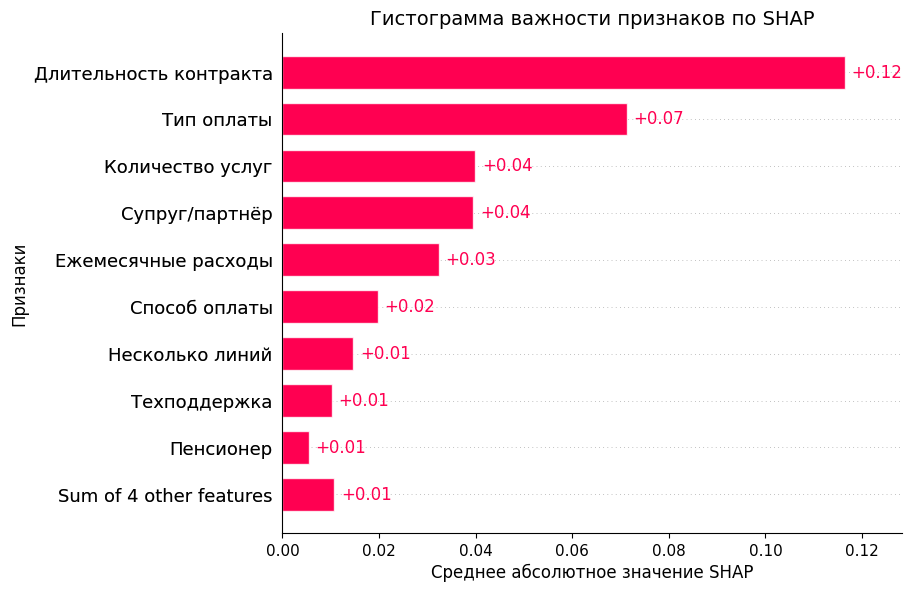

In [80]:
# Гистограмма важности признаков
plt.figure(figsize=(8, 6))
shap.plots.bar(shap_values_fixed, show=False)
plt.xlabel("Среднее абсолютное значение SHAP", fontsize=12)
plt.ylabel("Признаки", fontsize=12)
plt.title("Гистограмма важности признаков по SHAP", fontsize=14)
plt.show()

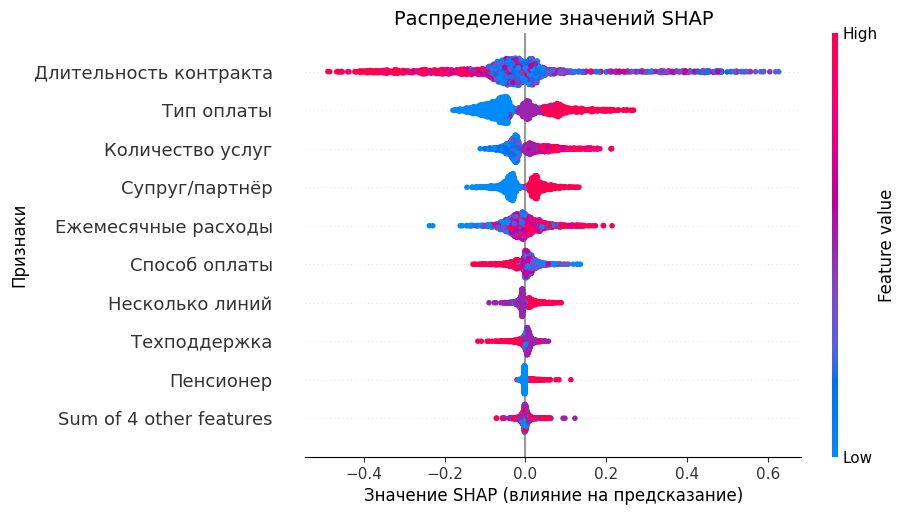

In [81]:
# Пчелиный рой
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values_fixed, show=False)
plt.xlabel("Значение SHAP (влияние на предсказание)", fontsize=12)
plt.ylabel("Признаки", fontsize=12)
plt.title("Распределение значений SHAP", fontsize=14)
plt.show()

Наиболее важными признаками для предсказаний модели являются: Длительность контракта и Тип оплаты. Также важными признаками являются Количество услуг, Наличие супруга/супруги и Размер ежемесячного платежа.

Построим график распределения длительности контракта с разбивкой по целевому признаку.

In [82]:
merged_df_rus

,ID клиента,Дата начала договора,Дата окончания договора,Тип оплаты,Электронный счет,Способ оплаты,Ежемесячные расходы,Общие расходы,Пол,Пенсионер,Есть супруг/супруга,Есть дети,Тип интернет-подключения,Блокировка опасных сайтов,Облачное резервное копирование,Антивирус,Техподдержка,Стриминговое ТВ,Стриминговые фильмы,Несколько телефонных линий,Договор расторгнут,Есть интернет,Есть телефон,Количество доп. услуг,Длительность до расторжения (дни),Текущая длительность контракта (дни),Дней с момента заключения договора,Длительность контракта,Длительность контракта (месяцев),Длительность контракта (месяцев) * Месячный платеж
0,7590-VHVEG,2020-01-01,NaT,Помесячно,Да,Электронный чек,29.85,31.04,Женщина,Нет,Да,Нет,DSL,Нет,Да,Нет,Нет,Нет,Нет,Не применимо,Нет,Да,Нет,1.0,NaN,31.0,31,31.0,1.033333,30.845000
1,5575-GNVDE,2017-04-01,NaT,1 год,Нет,Почтовый чек,56.95,2071.84,Мужчина,Нет,Нет,Нет,DSL,Да,Нет,Да,Нет,Нет,Нет,Нет,Нет,Да,Да,2.0,NaN,1036.0,1036,1036.0,34.533333,1966.673333
2,3668-QPYBK,2019-10-01,NaT,Помесячно,Да,Почтовый чек,53.85,226.17,Мужчина,Нет,Нет,Нет,DSL,Да,Да,Нет,Нет,Нет,Нет,Нет,Нет,Да,Да,2.0,NaN,123.0,123,123.0,4.100000,220.785000
3,7795-CFOCW,2016-05-01,NaT,1 год,Нет,Автоплатеж (перевод),42.30,1960.60,Мужчина,Нет,Нет,Нет,DSL,Да,Нет,Да,Да,Нет,Нет,Не применимо,Нет,Да,Нет,3.0,NaN,1371.0,1371,1371.0,45.700000,1933.110000
4,9237-HQITU,2019-09-01,NaT,Помесячно,Да,Электронный чек,70.70,353.50,Женщина,Нет,Нет,Нет,Оптоволокно,Нет,Нет,Нет,Нет,Нет,Нет,Нет,Нет,Да,Да,0.0,NaN,153.0,153,153.0,5.100000,360.570000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,2018-02-01,NaT,1 год,Да,Почтовый чек,84.80,2035.20,Мужчина,Нет,Да,Да,DSL,Да,Нет,Да,Да,Да,Да,Да,Нет,Да,Да,6.0,NaN,730.0,730,730.0,24.333333,2063.466667
7039,2234-XADUH,2014-02-01,NaT,1 год,Да,Автоплатеж (карта),103.20,7430.40,Женщина,Нет,Да,Да,Оптоволокно,Нет,Да,Да,Нет,Да,Да,Да,Нет,Да,Да,5.0,NaN,2191.0,2191,2191.0,73.033333,7537.040000
7040,4801-JZAZL,2019-03-01,NaT,Помесячно,Да,Электронный чек,29.60,325.60,Женщина,Нет,Да,Да,DSL,Да,Нет,Нет,Нет,Нет,Нет,Не применимо,Нет,Да,Нет,1.0,NaN,337.0,337,337.0,11.233333,332.506667
7041,8361-LTMKD,2019-07-01,NaT,Помесячно,Да,Почтовый чек,74.40,520.80,Мужчина,Да,Да,Нет,Оптоволокно,Нет,Нет,Нет,Нет,Нет,Нет,Да,Нет,Да,Да,1.0,NaN,215.0,215,215.0,7.166667,533.200000


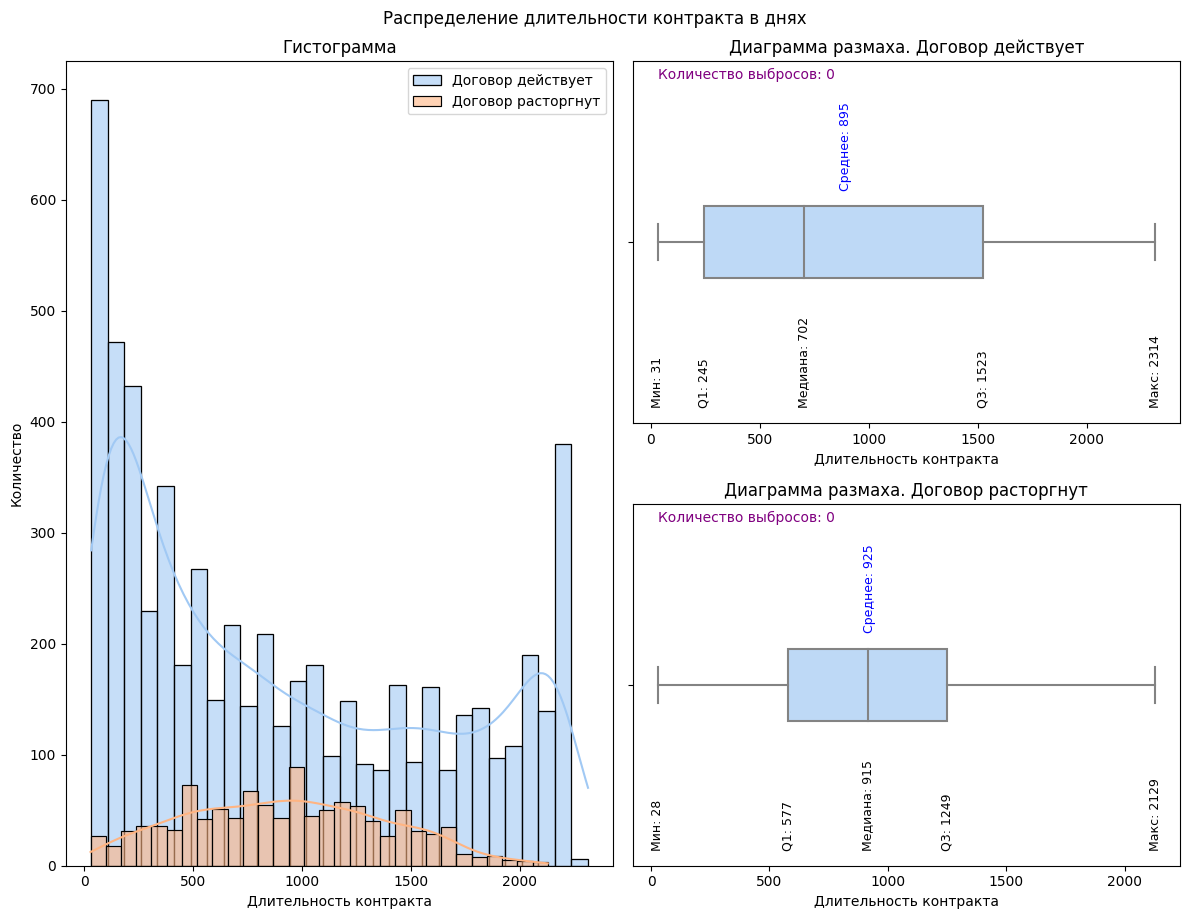

In [83]:
show_2_plots(merged_df_rus[merged_df_rus['Договор расторгнут'] == 'Нет'], merged_df_rus[merged_df_rus['Договор расторгнут'] == 'Да'], 
             'Длительность контракта', type='hist', new_bins=30, df_label='Договор действует', df2_label='Договор расторгнут', 
             main_title=f'Распределение длительности контракта в днях')

Имеется разница в распределениях для действующих и ушедших клиентов.

Среднее количество дней действия договора текущих клиентов 895, медианное - 702.<br>
Межквартильный размах от 245 до 1523.

Среднее количество дней действия договора ушедших клиентов 925, медианное - 915.<br>
Межквартильный размах от 577 до 1249.

<a class='anchor' id="link7"></a>
## Выводы

**Целью проекта** было построить модель, способную предсказывать вероятность расторжения договора, чтобы своевременно предлагать промокоды и специальные условия и снизить отток клиентов. Основная метрика ROC-AUC ≥ 0.85 на тестовой выборке.

Для этого были решены следующие **задачи**:
* Проведена загрузка, очистка и объединение данных из четырёх таблиц.
* Приведены типы данных и имена столбцов к единому стилю, обработаны пропуски и созданы новые признаки.
* Выполнен исследовательский анализ: изучены распределения признаков, выявлены корреляции.
* Сформирован портрет уходящего клиента.
* Подготовлены обучающие и тестовые выборки с учётом мультиколинеарности признаков и дисбаланса целевого признака.
* Обучены три модели: RandomForestClassifier, LGBMClassifier и нейросеть KerasClassifier.

**Основные результаты:**
Лучшую метрику показала модель LGBMClassifier: 
* ROC-AUC на тестовой выборке = 0.908
* Accuracy = 0.92
* Precision = 0.88
* Recall = 0.55

Основные признаки, влияющие на предсказание модели по убыванию важности: 
* Длительность контракта 
* Тип оплаты
* Количество доп. услуг
* Наличие супруга/супруги
* Размер ежемесячного платежа

Модель эффективно различает ушедших и действующих клиентов, хотя часть клиентов, расторгающих договор, остаётся не найденной.

**Рекомендации бизнесу:**
* Сосредоточить внимание на клиентах с высоким риском расторжения, основываясь на предсказанной вероятности.
* Предлагать промокоды, специальные условия и дополнительные услуги тем, кто наиболее вероятно расторгнет договор.
* Переводить клиентов на помесячную оплату, чтобы снизить риск расторжения.
* Для клиентов с высоким риском разрыва договора предлагать бесплатные или льготные услуги выделенной линии технической поддержки.
* Для "старых" клиентов внедрить систему лояльности, чтобы удерживать их дольше.
* Для семейных клиентов предлагать семейные подписки или пакеты услуг, повышающие ценность договора.

**Рекомендации для улучшения модели:**
* Попробовать добавить временные признаки (сезонность расторжений, активность пользователя).
* Рассмотреть дополнительные признаки о поведении клиентов, например, частоту обращений в техподдержку.
* Экспериментировать с архитектурой моделей, регуляризацией и гиперпараметрами для повышения качества предсказаний.
  
**Предложение для дальнейших исследований:**

Цель: Подобрать оптимальный порог классификации для лучшей модели при котором прибыль будет максимальной. <br>
Задача: Изменять пророг классификафии и оценивать разницу между выгодой от сохранения уходящих клиентов и потерями от специальных предложений тем клиентам, которые не собирались уходить и ошибочно были помечены как "уходящие".